# 📊 SHAP Interpretation Report: RANDOM_FOREST
This notebook provides a post-hoc explanation of the model's predictions using **tree** SHAP.

---

### 🔍 What are SHAP Values?
**SHAP (SHapley Additive exPlanations)** decomposes a model's prediction into the contribution of each individual feature. 
* **Magnitude:** A larger absolute SHAP value means the feature had a bigger impact on the output.
* **Direction:** A positive SHAP value means the feature pushed the prediction *higher*, while a negative value pushed it *lower*.
* **Interpretation:** For any given sample, the sum of SHAP values plus the base value (average model output) equals the actual model prediction.

### 🧪 Methodology
**Tree SHAP** is an optimized algorithm for tree-based models (like Random Forest or XGBoost). It leverages the internal structure of the trees to calculate exact SHAP values significantly faster than model-agnostic methods.

---

### 📋 Metadata
**Model Architecture:** RANDOM_FOREST  
**Analysis Context:** tabular  
**Dataset Scope:** whole

---


In [1]:
import shap
import numpy as np
import matplotlib.pyplot as plt

# Data provided by the explainer
all_shap_dict = {0: [[0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [0.06860562734013659, 0.05346615520152705, -0.3950717825416636], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [-0.34544293052944525, 0.048875748699339826, 0.023567181830105356], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [-0.09100000000000003, -0.09100000000000003, -0.09100000000000001], [0.06479771040915838, -0.3621473818104728, 0.024349671401314388], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [0.06479771040915838, -0.3621473818104728, 0.024349671401314388], [-0.09100000000000003, -0.09100000000000003, -0.09100000000000001], [-0.34544293052944525, 0.048875748699339826, 0.023567181830105356], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [-0.09100000000000003, -0.09100000000000003, -0.09100000000000001], [0.041075471698113215, -0.15703773584905664, -0.1570377358490566], [-0.15199124513618678, 0.03098249027237354, -0.15199124513618678], [0.041075471698113215, -0.15703773584905664, -0.1570377358490566], [0.06860562734013659, 0.05346615520152705, -0.3950717825416636], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [-0.15199124513618678, 0.03098249027237354, -0.15199124513618678], [0.06860562734013659, 0.05346615520152705, -0.39507178254166364], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [-0.09100000000000003, -0.09100000000000003, -0.09100000000000001], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [0.06479771040915838, -0.3621473818104728, 0.024349671401314388], [0.06479771040915838, -0.3621473818104728, 0.024349671401314388], [0.06860562734013659, 0.05346615520152705, -0.3950717825416636], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [0.06479771040915838, -0.3621473818104728, 0.024349671401314388], [-0.1435550561797753, -0.1435550561797753, 0.014110112359550559], [-0.15199124513618678, 0.03098249027237354, -0.15199124513618678], [0.06860562734013659, 0.05346615520152705, -0.39507178254166364], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [0.06860562734013659, 0.05346615520152705, -0.3950717825416636], [-0.15199124513618678, 0.03098249027237354, -0.15199124513618678], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [-0.09100000000000003, -0.09100000000000003, -0.09100000000000001], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [-0.09100000000000003, -0.09100000000000003, -0.09100000000000001], [0.06860562734013659, 0.05346615520152705, -0.39507178254166364], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [-0.15199124513618678, 0.03098249027237354, -0.15199124513618678], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [-0.34544293052944525, 0.048875748699339826, 0.023567181830105356], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [-0.34544293052944525, 0.048875748699339826, 0.023567181830105356], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [-0.09100000000000003, -0.09100000000000003, -0.09100000000000001], [0.041075471698113215, -0.15703773584905664, -0.1570377358490566], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [-0.15199124513618678, 0.03098249027237354, -0.15199124513618678], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [-0.34544293052944525, 0.048875748699339826, 0.023567181830105356], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [0.06860562734013659, 0.05346615520152705, -0.39507178254166364], [-0.15199124513618678, 0.03098249027237354, -0.15199124513618678], [-0.1435550561797753, -0.1435550561797753, 0.014110112359550559], [0.041075471698113215, -0.15703773584905664, -0.1570377358490566], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [0.041075471698113215, -0.15703773584905664, -0.1570377358490566], [-0.09100000000000003, -0.09100000000000003, -0.09100000000000001], [-0.09100000000000003, -0.09100000000000003, -0.09100000000000001], [-0.09100000000000003, -0.09100000000000003, -0.09100000000000001], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [-0.09100000000000003, -0.09100000000000003, -0.09100000000000001], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [0.041075471698113215, -0.15703773584905664, -0.1570377358490566], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [0.06479771040915838, -0.3621473818104728, 0.024349671401314388], [-0.34544293052944525, 0.048875748699339826, 0.023567181830105356], [0.041075471698113215, -0.15703773584905664, -0.1570377358490566], [-0.09100000000000003, -0.09100000000000003, -0.09100000000000001], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [0.06860562734013659, 0.05346615520152705, -0.39507178254166364], [-0.09100000000000003, -0.09100000000000003, -0.09100000000000001], [-0.09100000000000003, -0.09100000000000003, -0.09100000000000001], [-0.09100000000000003, -0.09100000000000003, -0.09100000000000001], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [-0.15199124513618678, 0.03098249027237354, -0.15199124513618678], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [0.041075471698113215, -0.15703773584905664, -0.1570377358490566], [0.06479771040915838, -0.3621473818104728, 0.024349671401314388], [0.041075471698113215, -0.15703773584905664, -0.1570377358490566], [0.06479771040915838, -0.3621473818104728, 0.024349671401314388], [0.041075471698113215, -0.15703773584905664, -0.1570377358490566], [0.06860562734013659, 0.05346615520152705, -0.39507178254166364], [-0.15199124513618678, 0.03098249027237354, -0.15199124513618678], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [-0.09100000000000003, -0.09100000000000003, -0.09100000000000001], [0.06860562734013659, 0.05346615520152705, -0.39507178254166364], [-0.34544293052944525, 0.048875748699339826, 0.023567181830105356], [-0.09100000000000003, -0.09100000000000003, -0.09100000000000001], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [-0.09100000000000003, -0.09100000000000003, -0.09100000000000001], [0.06860562734013659, 0.05346615520152705, -0.3950717825416636], [-0.09100000000000003, -0.09100000000000003, -0.09100000000000001], [0.06479771040915838, -0.3621473818104728, 0.024349671401314388], [-0.15199124513618678, 0.03098249027237354, -0.15199124513618678], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [-0.1435550561797753, -0.1435550561797753, 0.014110112359550559], [-0.15199124513618678, 0.03098249027237354, -0.15199124513618678], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [0.06479771040915838, -0.3621473818104728, 0.024349671401314388], [0.06479771040915838, -0.3621473818104728, 0.024349671401314388], [-0.15199124513618678, 0.03098249027237354, -0.15199124513618678], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [0.041075471698113215, -0.15703773584905664, -0.1570377358490566], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [-0.09100000000000003, -0.09100000000000003, -0.09100000000000001], [-0.09100000000000003, -0.09100000000000003, -0.09100000000000001], [-0.09100000000000003, -0.09100000000000003, -0.09100000000000001], [-0.15199124513618678, 0.03098249027237354, -0.15199124513618678], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [0.06479771040915838, -0.3621473818104728, 0.024349671401314388], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [0.041075471698113215, -0.15703773584905664, -0.1570377358490566], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [0.041075471698113215, -0.15703773584905664, -0.1570377358490566], [0.06860562734013659, 0.05346615520152705, -0.3950717825416636], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [-0.09100000000000003, -0.09100000000000003, -0.09100000000000001], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [-0.15199124513618678, 0.03098249027237354, -0.15199124513618678], [-0.15199124513618678, 0.03098249027237354, -0.15199124513618678], [-0.09100000000000003, -0.09100000000000003, -0.09100000000000001], [-0.09100000000000003, -0.09100000000000003, -0.09100000000000001], [0.06479771040915838, -0.3621473818104728, 0.024349671401314388], [-0.34544293052944525, 0.048875748699339826, 0.023567181830105356], [0.041075471698113215, -0.15703773584905664, -0.1570377358490566], [0.06479771040915838, -0.3621473818104728, 0.024349671401314388], [-0.34544293052944525, 0.048875748699339826, 0.023567181830105356], [-0.09100000000000003, -0.09100000000000003, -0.09100000000000001], [-0.1435550561797753, -0.1435550561797753, 0.014110112359550559], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [-0.34544293052944525, 0.048875748699339826, 0.023567181830105356], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [-0.09100000000000003, -0.09100000000000003, -0.09100000000000001], [0.041075471698113215, -0.15703773584905664, -0.1570377358490566], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [0.041075471698113215, -0.15703773584905664, -0.1570377358490566], [-0.1435550561797753, -0.1435550561797753, 0.014110112359550559], [0.06860562734013659, 0.05346615520152705, -0.3950717825416636], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [0.041075471698113215, -0.15703773584905664, -0.1570377358490566], [-0.15199124513618678, 0.03098249027237354, -0.15199124513618678], [0.06860562734013659, 0.05346615520152705, -0.39507178254166364], [-0.34544293052944525, 0.048875748699339826, 0.023567181830105356], [0.06860562734013659, 0.05346615520152705, -0.3950717825416636], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [-0.09100000000000003, -0.09100000000000003, -0.09100000000000001], [0.06479771040915838, -0.3621473818104728, 0.024349671401314388], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [-0.15199124513618678, 0.03098249027237354, -0.15199124513618678], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [0.041075471698113215, -0.15703773584905664, -0.1570377358490566], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [-0.15199124513618678, 0.03098249027237354, -0.15199124513618678], [0.041075471698113215, -0.15703773584905664, -0.1570377358490566], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [0.041075471698113215, -0.15703773584905664, -0.1570377358490566], [-0.09100000000000003, -0.09100000000000003, -0.09100000000000001], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [0.041075471698113215, -0.15703773584905664, -0.1570377358490566], [-0.34544293052944525, 0.048875748699339826, 0.023567181830105356], [0.041075471698113215, -0.15703773584905664, -0.1570377358490566], [-0.15199124513618678, 0.03098249027237354, -0.15199124513618678], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [-0.09100000000000003, -0.09100000000000003, -0.09100000000000001], [-0.15199124513618678, 0.03098249027237354, -0.15199124513618678], [0.06860562734013659, 0.05346615520152705, -0.39507178254166364], [-0.09100000000000003, -0.09100000000000003, -0.09100000000000001], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [0.041075471698113215, -0.15703773584905664, -0.1570377358490566], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [-0.15199124513618678, 0.03098249027237354, -0.15199124513618678], [0.06479771040915838, -0.3621473818104728, 0.024349671401314388], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [0.041075471698113215, -0.15703773584905664, -0.1570377358490566], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [-0.34544293052944525, 0.048875748699339826, 0.023567181830105356], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [-0.09100000000000003, -0.09100000000000003, -0.09100000000000001], [-0.15199124513618678, 0.03098249027237354, -0.15199124513618678], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [0.06860562734013659, 0.05346615520152705, -0.39507178254166364], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [-0.34544293052944525, 0.048875748699339826, 0.023567181830105356], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [-0.15199124513618678, 0.03098249027237354, -0.15199124513618678], [-0.09100000000000003, -0.09100000000000003, -0.09100000000000001], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [0.06479771040915838, -0.3621473818104728, 0.024349671401314388], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [-0.15199124513618678, 0.03098249027237354, -0.15199124513618678], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [-0.09100000000000003, -0.09100000000000003, -0.09100000000000001], [0.06860562734013659, 0.05346615520152705, -0.3950717825416636], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [-0.09100000000000003, -0.09100000000000003, -0.09100000000000001], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [-0.15199124513618678, 0.03098249027237354, -0.15199124513618678], [-0.15199124513618678, 0.03098249027237354, -0.15199124513618678], [-0.09100000000000003, -0.09100000000000003, -0.09100000000000001], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [0.06479771040915838, -0.3621473818104728, 0.024349671401314388], [-0.09100000000000003, -0.09100000000000003, -0.09100000000000001], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [-0.09100000000000003, -0.09100000000000003, -0.09100000000000001], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [-0.09100000000000003, -0.09100000000000003, -0.09100000000000001], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [-0.34544293052944525, 0.048875748699339826, 0.023567181830105356], [0.06479771040915838, -0.3621473818104728, 0.024349671401314388], [-0.1435550561797753, -0.1435550561797753, 0.014110112359550559], [-0.09100000000000003, -0.09100000000000003, -0.09100000000000001], [-0.34544293052944525, 0.048875748699339826, 0.023567181830105356], [0.041075471698113215, -0.15703773584905664, -0.1570377358490566], [-0.15199124513618678, 0.03098249027237354, -0.15199124513618678], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [0.041075471698113215, -0.15703773584905664, -0.1570377358490566], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [-0.09100000000000003, -0.09100000000000003, -0.09100000000000001], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [-0.15199124513618678, 0.03098249027237354, -0.15199124513618678], [0.06860562734013659, 0.05346615520152705, -0.3950717825416636], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [0.06479771040915838, -0.3621473818104728, 0.024349671401314388], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [0.06479771040915838, -0.3621473818104728, 0.024349671401314388], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [-0.15199124513618678, 0.03098249027237354, -0.15199124513618678], [-0.15199124513618678, 0.03098249027237354, -0.15199124513618678], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [0.06860562734013659, 0.05346615520152705, -0.39507178254166364], [0.06479771040915838, -0.3621473818104728, 0.024349671401314388], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [-0.15199124513618678, 0.03098249027237354, -0.15199124513618678], [-0.09100000000000003, -0.09100000000000003, -0.09100000000000001], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [0.06860562734013659, 0.05346615520152705, -0.3950717825416636], [0.06860562734013659, 0.05346615520152705, -0.3950717825416636], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [-0.09100000000000003, -0.09100000000000003, -0.09100000000000001], [-0.09100000000000003, -0.09100000000000003, -0.09100000000000001], [0.06479771040915838, -0.3621473818104728, 0.024349671401314388], [-0.09100000000000003, -0.09100000000000003, -0.09100000000000001], [-0.09100000000000003, -0.09100000000000003, -0.09100000000000001], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [0.041075471698113215, -0.15703773584905664, -0.1570377358490566], [-0.09100000000000003, -0.09100000000000003, -0.09100000000000001], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [0.06479771040915838, -0.3621473818104728, 0.024349671401314388], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [-0.15199124513618678, 0.03098249027237354, -0.15199124513618678], [-0.09100000000000003, -0.09100000000000003, -0.09100000000000001], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [0.06479771040915838, -0.3621473818104728, 0.024349671401314388], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [-0.1435550561797753, -0.1435550561797753, 0.014110112359550559], [0.06860562734013659, 0.05346615520152705, -0.3950717825416636], [-0.34544293052944525, 0.048875748699339826, 0.023567181830105356], [0.06860562734013659, 0.05346615520152705, -0.39507178254166364], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [0.06479771040915838, -0.3621473818104728, 0.024349671401314388], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [0.06479771040915838, -0.3621473818104728, 0.024349671401314388], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [0.041075471698113215, -0.15703773584905664, -0.1570377358490566], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [-0.15199124513618678, 0.03098249027237354, -0.15199124513618678], [0.041075471698113215, -0.15703773584905664, -0.1570377358490566], [-0.15199124513618678, 0.03098249027237354, -0.15199124513618678], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [0.041075471698113215, -0.15703773584905664, -0.1570377358490566], [-0.09100000000000003, -0.09100000000000003, -0.09100000000000001], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [-0.1435550561797753, -0.1435550561797753, 0.014110112359550559], [0.06479771040915838, -0.3621473818104728, 0.024349671401314388], [0.041075471698113215, -0.15703773584905664, -0.1570377358490566], [0.06479771040915838, -0.3621473818104728, 0.024349671401314388], [-0.09100000000000003, -0.09100000000000003, -0.09100000000000001], [-0.09100000000000003, -0.09100000000000003, -0.09100000000000001], [-0.09100000000000003, -0.09100000000000003, -0.09100000000000001], [-0.09100000000000003, -0.09100000000000003, -0.09100000000000001], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [-0.34544293052944525, 0.048875748699339826, 0.023567181830105356], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [0.06479771040915838, -0.3621473818104728, 0.024349671401314388], [0.041075471698113215, -0.15703773584905664, -0.1570377358490566], [0.041075471698113215, -0.15703773584905664, -0.1570377358490566], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [-0.15199124513618678, 0.03098249027237354, -0.15199124513618678], [0.06479771040915838, -0.3621473818104728, 0.024349671401314388], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [0.041075471698113215, -0.15703773584905664, -0.1570377358490566], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [0.041075471698113215, -0.15703773584905664, -0.1570377358490566], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [-0.15199124513618678, 0.03098249027237354, -0.15199124513618678], [0.06479771040915838, -0.3621473818104728, 0.024349671401314388], [0.041075471698113215, -0.15703773584905664, -0.1570377358490566], [-0.15199124513618678, 0.03098249027237354, -0.15199124513618678], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [-0.34544293052944525, 0.048875748699339826, 0.023567181830105356], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [0.06479771040915838, -0.3621473818104728, 0.024349671401314388], [0.06479771040915838, -0.3621473818104728, 0.024349671401314388], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [-0.09100000000000003, -0.09100000000000003, -0.09100000000000001], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [0.041075471698113215, -0.15703773584905664, -0.1570377358490566], [0.041075471698113215, -0.15703773584905664, -0.1570377358490566], [0.06860562734013659, 0.05346615520152705, -0.39507178254166364], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [0.041075471698113215, -0.15703773584905664, -0.1570377358490566], [0.06860562734013659, 0.05346615520152705, -0.39507178254166364], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [0.06479771040915838, -0.3621473818104728, 0.024349671401314388], [0.041075471698113215, -0.15703773584905664, -0.1570377358490566], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [-0.09100000000000003, -0.09100000000000003, -0.09100000000000001], [0.041075471698113215, -0.15703773584905664, -0.1570377358490566], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [-0.09100000000000003, -0.09100000000000003, -0.09100000000000001], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [0.06860562734013659, 0.05346615520152705, -0.3950717825416636], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [0.06479771040915838, -0.3621473818104728, 0.024349671401314388], [0.06479771040915838, -0.3621473818104728, 0.024349671401314388], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [-0.15199124513618678, 0.03098249027237354, -0.15199124513618678], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [-0.09100000000000003, -0.09100000000000003, -0.09100000000000001], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [-0.34544293052944525, 0.048875748699339826, 0.023567181830105356], [0.041075471698113215, -0.15703773584905664, -0.1570377358490566], [0.06479771040915838, -0.3621473818104728, 0.024349671401314388], [-0.34544293052944525, 0.048875748699339826, 0.023567181830105356], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [0.06860562734013659, 0.05346615520152705, -0.39507178254166364], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [0.06479771040915838, -0.3621473818104728, 0.024349671401314388], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [0.041075471698113215, -0.15703773584905664, -0.1570377358490566], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [-0.15199124513618678, 0.03098249027237354, -0.15199124513618678], [-0.09100000000000003, -0.09100000000000003, -0.09100000000000001], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [0.06860562734013659, 0.05346615520152705, -0.3950717825416636], [0.06860562734013659, 0.05346615520152705, -0.39507178254166364], [-0.15199124513618678, 0.03098249027237354, -0.15199124513618678], [-0.15199124513618678, 0.03098249027237354, -0.15199124513618678], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [-0.15199124513618678, 0.03098249027237354, -0.15199124513618678], [-0.15199124513618678, 0.03098249027237354, -0.15199124513618678], [-0.09100000000000003, -0.09100000000000003, -0.09100000000000001], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [0.041075471698113215, -0.15703773584905664, -0.1570377358490566], [-0.1435550561797753, -0.1435550561797753, 0.014110112359550559], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [-0.09100000000000003, -0.09100000000000003, -0.09100000000000001], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [0.06860562734013659, 0.05346615520152705, -0.39507178254166364], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [0.06479771040915838, -0.3621473818104728, 0.024349671401314388], [0.06479771040915838, -0.3621473818104728, 0.024349671401314388], [-0.09100000000000003, -0.09100000000000003, -0.09100000000000001], [-0.1435550561797753, -0.1435550561797753, 0.014110112359550559], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [-0.15199124513618678, 0.03098249027237354, -0.15199124513618678], [0.041075471698113215, -0.15703773584905664, -0.1570377358490566], [0.06860562734013659, 0.05346615520152705, -0.3950717825416636], [-0.15199124513618678, 0.03098249027237354, -0.15199124513618678], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [-0.09100000000000003, -0.09100000000000003, -0.09100000000000001], [-0.09100000000000003, -0.09100000000000003, -0.09100000000000001], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [0.06860562734013659, 0.05346615520152705, -0.3950717825416636], [-0.34544293052944525, 0.048875748699339826, 0.023567181830105356], [-0.15199124513618678, 0.03098249027237354, -0.15199124513618678], [0.06479771040915838, -0.3621473818104728, 0.024349671401314388], [0.041075471698113215, -0.15703773584905664, -0.1570377358490566], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [0.041075471698113215, -0.15703773584905664, -0.1570377358490566], [-0.15199124513618678, 0.03098249027237354, -0.15199124513618678], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [-0.09100000000000003, -0.09100000000000003, -0.09100000000000001], [-0.1435550561797753, -0.1435550561797753, 0.014110112359550559], [-0.15199124513618678, 0.03098249027237354, -0.15199124513618678], [-0.15199124513618678, 0.03098249027237354, -0.15199124513618678], [0.06860562734013659, 0.05346615520152705, -0.3950717825416636], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [0.06860562734013659, 0.05346615520152705, -0.39507178254166364], [0.06479771040915838, -0.3621473818104728, 0.024349671401314388], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [-0.09100000000000003, -0.09100000000000003, -0.09100000000000001], [-0.1435550561797753, -0.1435550561797753, 0.014110112359550559], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [-0.09100000000000003, -0.09100000000000003, -0.09100000000000001], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [-0.09100000000000003, -0.09100000000000003, -0.09100000000000001], [-0.1435550561797753, -0.1435550561797753, 0.014110112359550559], [0.06479771040915838, -0.3621473818104728, 0.024349671401314388], [-0.15199124513618678, 0.03098249027237354, -0.15199124513618678], [0.06860562734013659, 0.05346615520152705, -0.39507178254166364], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [0.06479771040915838, -0.3621473818104728, 0.024349671401314388], [-0.15199124513618678, 0.03098249027237354, -0.15199124513618678], [0.041075471698113215, -0.15703773584905664, -0.1570377358490566], [-0.09100000000000003, -0.09100000000000003, -0.09100000000000001], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [0.06860562734013659, 0.05346615520152705, -0.39507178254166364], [0.06860562734013659, 0.05346615520152705, -0.3950717825416636], [0.06860562734013659, 0.05346615520152705, -0.3950717825416636], [-0.09100000000000003, -0.09100000000000003, -0.09100000000000001], [-0.15199124513618678, 0.03098249027237354, -0.15199124513618678], [-0.34544293052944525, 0.048875748699339826, 0.023567181830105356], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [0.06860562734013659, 0.05346615520152705, -0.3950717825416636], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [0.06479771040915838, -0.3621473818104728, 0.024349671401314388], [-0.09100000000000003, -0.09100000000000003, -0.09100000000000001], [-0.15199124513618678, 0.03098249027237354, -0.15199124513618678], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [0.06860562734013659, 0.05346615520152705, -0.39507178254166364], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [-0.09100000000000003, -0.09100000000000003, -0.09100000000000001], [0.06479771040915838, -0.3621473818104728, 0.024349671401314388], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [-0.09100000000000003, -0.09100000000000003, -0.09100000000000001], [-0.09100000000000003, -0.09100000000000003, -0.09100000000000001], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [-0.09100000000000003, -0.09100000000000003, -0.09100000000000001], [-0.34544293052944525, 0.048875748699339826, 0.023567181830105356], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [-0.34544293052944525, 0.048875748699339826, 0.023567181830105356], [-0.09100000000000003, -0.09100000000000003, -0.09100000000000001], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [0.06479771040915838, -0.3621473818104728, 0.024349671401314388], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [0.06479771040915838, -0.3621473818104728, 0.024349671401314388], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [-0.15199124513618678, 0.03098249027237354, -0.15199124513618678], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [-0.15199124513618678, 0.03098249027237354, -0.15199124513618678], [-0.09100000000000003, -0.09100000000000003, -0.09100000000000001], [-0.09100000000000003, -0.09100000000000003, -0.09100000000000001], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [-0.09100000000000003, -0.09100000000000003, -0.09100000000000001], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [-0.09100000000000003, -0.09100000000000003, -0.09100000000000001], [-0.1435550561797753, -0.1435550561797753, 0.014110112359550559], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [0.06860562734013659, 0.05346615520152705, -0.3950717825416636], [-0.09100000000000003, -0.09100000000000003, -0.09100000000000001], [0.041075471698113215, -0.15703773584905664, -0.1570377358490566], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [0.06479771040915838, -0.3621473818104728, 0.024349671401314388], [-0.34544293052944525, 0.048875748699339826, 0.023567181830105356], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [-0.34544293052944525, 0.048875748699339826, 0.023567181830105356], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [-0.09100000000000003, -0.09100000000000003, -0.09100000000000001], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [0.06479771040915838, -0.3621473818104728, 0.024349671401314388], [0.06479771040915838, -0.3621473818104728, 0.024349671401314388], [-0.15199124513618678, 0.03098249027237354, -0.15199124513618678], [-0.09100000000000003, -0.09100000000000003, -0.09100000000000001], [0.06860562734013659, 0.05346615520152705, -0.3950717825416636], [0.06860562734013659, 0.05346615520152705, -0.3950717825416636], [-0.09100000000000003, -0.09100000000000003, -0.09100000000000001], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [0.041075471698113215, -0.15703773584905664, -0.1570377358490566], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [-0.34544293052944525, 0.048875748699339826, 0.023567181830105356], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [-0.09100000000000003, -0.09100000000000003, -0.09100000000000001], [0.06860562734013659, 0.05346615520152705, -0.39507178254166364], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [0.06860562734013659, 0.05346615520152705, -0.3950717825416636], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [0.06860562734013659, 0.05346615520152705, -0.3950717825416636], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [0.06860562734013659, 0.05346615520152705, -0.3950717825416636], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [0.06479771040915838, -0.3621473818104728, 0.024349671401314388], [0.06860562734013659, 0.05346615520152705, -0.39507178254166364], [0.041075471698113215, -0.15703773584905664, -0.1570377358490566], [-0.09100000000000003, -0.09100000000000003, -0.09100000000000001], [0.041075471698113215, -0.15703773584905664, -0.1570377358490566], [-0.1435550561797753, -0.1435550561797753, 0.014110112359550559], [0.06479771040915838, -0.3621473818104728, 0.024349671401314388], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [0.041075471698113215, -0.15703773584905664, -0.1570377358490566], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [-0.09100000000000003, -0.09100000000000003, -0.09100000000000001], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [0.041075471698113215, -0.15703773584905664, -0.1570377358490566], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [-0.1435550561797753, -0.1435550561797753, 0.014110112359550559], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [0.06860562734013659, 0.05346615520152705, -0.3950717825416636], [0.06479771040915838, -0.3621473818104728, 0.024349671401314388], [-0.09100000000000003, -0.09100000000000003, -0.09100000000000001], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [0.06860562734013659, 0.05346615520152705, -0.39507178254166364], [-0.09100000000000003, -0.09100000000000003, -0.09100000000000001], [-0.09100000000000003, -0.09100000000000003, -0.09100000000000001], [-0.1435550561797753, -0.1435550561797753, 0.014110112359550559], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [-0.34544293052944525, 0.048875748699339826, 0.023567181830105356], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [0.06479771040915838, -0.3621473818104728, 0.024349671401314388], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [-0.1435550561797753, -0.1435550561797753, 0.014110112359550559], [-0.15199124513618678, 0.03098249027237354, -0.15199124513618678], [0.041075471698113215, -0.15703773584905664, -0.1570377358490566], [-0.1435550561797753, -0.1435550561797753, 0.014110112359550559], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [-0.15199124513618678, 0.03098249027237354, -0.15199124513618678], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [0.06860562734013659, 0.05346615520152705, -0.3950717825416636], [0.06860562734013659, 0.05346615520152705, -0.39507178254166364], [0.06860562734013659, 0.05346615520152705, -0.39507178254166364], [-0.09100000000000003, -0.09100000000000003, -0.09100000000000001], [0.041075471698113215, -0.15703773584905664, -0.1570377358490566], [-0.15199124513618678, 0.03098249027237354, -0.15199124513618678], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [0.041075471698113215, -0.15703773584905664, -0.1570377358490566], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [0.06860562734013659, 0.05346615520152705, -0.3950717825416636], [-0.09100000000000003, -0.09100000000000003, -0.09100000000000001], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [0.06479771040915838, -0.3621473818104728, 0.024349671401314388], [-0.15199124513618678, 0.03098249027237354, -0.15199124513618678], [-0.1435550561797753, -0.1435550561797753, 0.014110112359550559], [-0.15199124513618678, 0.03098249027237354, -0.15199124513618678], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [-0.09100000000000003, -0.09100000000000003, -0.09100000000000001], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [-0.15199124513618678, 0.03098249027237354, -0.15199124513618678], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [-0.34544293052944525, 0.048875748699339826, 0.023567181830105356], [0.06860562734013659, 0.05346615520152705, -0.39507178254166364], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [-0.15199124513618678, 0.03098249027237354, -0.15199124513618678], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [-0.15199124513618678, 0.03098249027237354, -0.15199124513618678], [-0.09100000000000003, -0.09100000000000003, -0.09100000000000001], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [-0.09100000000000003, -0.09100000000000003, -0.09100000000000001], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [-0.09100000000000003, -0.09100000000000003, -0.09100000000000001], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [0.041075471698113215, -0.15703773584905664, -0.1570377358490566], [-0.1435550561797753, -0.1435550561797753, 0.014110112359550559], [-0.1435550561797753, -0.1435550561797753, 0.014110112359550559], [0.06479771040915838, -0.3621473818104728, 0.024349671401314388], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [-0.09100000000000003, -0.09100000000000003, -0.09100000000000001], [0.06479771040915838, -0.3621473818104728, 0.024349671401314388], [-0.09100000000000003, -0.09100000000000003, -0.09100000000000001], [0.041075471698113215, -0.15703773584905664, -0.1570377358490566], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [0.06479771040915838, -0.3621473818104728, 0.024349671401314388], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [-0.15199124513618678, 0.03098249027237354, -0.15199124513618678], [0.06479771040915838, -0.3621473818104728, 0.024349671401314388], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [0.041075471698113215, -0.15703773584905664, -0.1570377358490566], [-0.15199124513618678, 0.03098249027237354, -0.15199124513618678], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [-0.34544293052944525, 0.048875748699339826, 0.023567181830105356], [0.041075471698113215, -0.15703773584905664, -0.1570377358490566], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [-0.1435550561797753, -0.1435550561797753, 0.014110112359550559], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [-0.15199124513618678, 0.03098249027237354, -0.15199124513618678], [-0.09100000000000003, -0.09100000000000003, -0.09100000000000001], [-0.34544293052944525, 0.048875748699339826, 0.023567181830105356], [0.041075471698113215, -0.15703773584905664, -0.1570377358490566], [0.06860562734013659, 0.05346615520152705, -0.3950717825416636], [0.041075471698113215, -0.15703773584905664, -0.1570377358490566], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [-0.15199124513618678, 0.03098249027237354, -0.15199124513618678], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [0.041075471698113215, -0.15703773584905664, -0.1570377358490566], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [0.06479771040915838, -0.3621473818104728, 0.024349671401314388], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [0.06479771040915838, -0.3621473818104728, 0.024349671401314388], [-0.1435550561797753, -0.1435550561797753, 0.014110112359550559], [0.041075471698113215, -0.15703773584905664, -0.1570377358490566], [-0.1435550561797753, -0.1435550561797753, 0.014110112359550559], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [0.06860562734013659, 0.05346615520152705, -0.39507178254166364], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [0.06860562734013659, 0.05346615520152705, -0.39507178254166364], [0.06860562734013659, 0.05346615520152705, -0.3950717825416636], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [-0.1435550561797753, -0.1435550561797753, 0.014110112359550559], [-0.1435550561797753, -0.1435550561797753, 0.014110112359550559], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [-0.09100000000000003, -0.09100000000000003, -0.09100000000000001], [-0.09100000000000003, -0.09100000000000003, -0.09100000000000001], [-0.34544293052944525, 0.048875748699339826, 0.023567181830105356], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [-0.15199124513618678, 0.03098249027237354, -0.15199124513618678], [-0.15199124513618678, 0.03098249027237354, -0.15199124513618678], [-0.09100000000000003, -0.09100000000000003, -0.09100000000000001], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [-0.34544293052944525, 0.048875748699339826, 0.023567181830105356], [-0.09100000000000003, -0.09100000000000003, -0.09100000000000001], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [-0.34544293052944525, 0.048875748699339826, 0.023567181830105356], [0.06860562734013659, 0.05346615520152705, -0.39507178254166364], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [-0.09100000000000003, -0.09100000000000003, -0.09100000000000001], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [-0.1435550561797753, -0.1435550561797753, 0.014110112359550559], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [0.041075471698113215, -0.15703773584905664, -0.1570377358490566], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [0.06479771040915838, -0.3621473818104728, 0.024349671401314388], [-0.1435550561797753, -0.1435550561797753, 0.014110112359550559], [-0.34544293052944525, 0.048875748699339826, 0.023567181830105356], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [0.041075471698113215, -0.15703773584905664, -0.1570377358490566], [-0.1435550561797753, -0.1435550561797753, 0.014110112359550559], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [0.06479771040915838, -0.3621473818104728, 0.024349671401314388], [0.06860562734013659, 0.05346615520152705, -0.39507178254166364], [-0.34544293052944525, 0.048875748699339826, 0.023567181830105356], [0.06479771040915838, -0.3621473818104728, 0.024349671401314388], [0.041075471698113215, -0.15703773584905664, -0.1570377358490566], [-0.09100000000000003, -0.09100000000000003, -0.09100000000000001], [0.06860562734013659, 0.05346615520152705, -0.39507178254166364], [0.06860562734013659, 0.05346615520152705, -0.3950717825416636], [-0.09100000000000003, -0.09100000000000003, -0.09100000000000001], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [-0.09100000000000003, -0.09100000000000003, -0.09100000000000001], [-0.15199124513618678, 0.03098249027237354, -0.15199124513618678], [0.06479771040915838, -0.3621473818104728, 0.024349671401314388], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [0.041075471698113215, -0.15703773584905664, -0.1570377358490566], [-0.09100000000000003, -0.09100000000000003, -0.09100000000000001], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [-0.15199124513618678, 0.03098249027237354, -0.15199124513618678], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [0.06860562734013659, 0.05346615520152705, -0.3950717825416636], [0.06479771040915838, -0.3621473818104728, 0.024349671401314388], [-0.15199124513618678, 0.03098249027237354, -0.15199124513618678], [0.041075471698113215, -0.15703773584905664, -0.1570377358490566], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [-0.09100000000000003, -0.09100000000000003, -0.09100000000000001], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [-0.09100000000000003, -0.09100000000000003, -0.09100000000000001], [0.06860562734013659, 0.05346615520152705, -0.39507178254166364], [0.06860562734013659, 0.05346615520152705, -0.3950717825416636], [-0.09100000000000003, -0.09100000000000003, -0.09100000000000001], [0.06860562734013659, 0.05346615520152705, -0.39507178254166364], [-0.1435550561797753, -0.1435550561797753, 0.014110112359550559], [-0.15199124513618678, 0.03098249027237354, -0.15199124513618678], [0.06479771040915838, -0.3621473818104728, 0.024349671401314388], [-0.09100000000000003, -0.09100000000000003, -0.09100000000000001], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [-0.09100000000000003, -0.09100000000000003, -0.09100000000000001], [0.06479771040915838, -0.3621473818104728, 0.024349671401314388], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [0.041075471698113215, -0.15703773584905664, -0.1570377358490566], [-0.09100000000000003, -0.09100000000000003, -0.09100000000000001], [-0.15199124513618678, 0.03098249027237354, -0.15199124513618678], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [-0.09100000000000003, -0.09100000000000003, -0.09100000000000001], [0.06479771040915838, -0.3621473818104728, 0.024349671401314388], [-0.1435550561797753, -0.1435550561797753, 0.014110112359550559], [-0.34544293052944525, 0.048875748699339826, 0.023567181830105356], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [-0.09100000000000003, -0.09100000000000003, -0.09100000000000001], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [-0.09100000000000003, -0.09100000000000003, -0.09100000000000001], [-0.09100000000000003, -0.09100000000000003, -0.09100000000000001], [-0.09100000000000003, -0.09100000000000003, -0.09100000000000001], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [0.041075471698113215, -0.15703773584905664, -0.1570377358490566], [0.06479771040915838, -0.3621473818104728, 0.024349671401314388], [0.041075471698113215, -0.15703773584905664, -0.1570377358490566], [0.041075471698113215, -0.15703773584905664, -0.1570377358490566], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [-0.09100000000000003, -0.09100000000000003, -0.09100000000000001], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [-0.15199124513618678, 0.03098249027237354, -0.15199124513618678], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [-0.09100000000000003, -0.09100000000000003, -0.09100000000000001], [-0.09100000000000003, -0.09100000000000003, -0.09100000000000001], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [-0.09100000000000003, -0.09100000000000003, -0.09100000000000001], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [-0.1435550561797753, -0.1435550561797753, 0.014110112359550559], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [0.06479771040915838, -0.3621473818104728, 0.024349671401314388], [0.06479771040915838, -0.3621473818104728, 0.024349671401314388], [-0.34544293052944525, 0.048875748699339826, 0.023567181830105356], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [-0.34544293052944525, 0.048875748699339826, 0.023567181830105356], [-0.09100000000000003, -0.09100000000000003, -0.09100000000000001], [-0.1435550561797753, -0.1435550561797753, 0.014110112359550559], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [0.06860562734013659, 0.05346615520152705, -0.39507178254166364], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [0.06860562734013659, 0.05346615520152705, -0.3950717825416636], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [0.06860562734013659, 0.05346615520152705, -0.39507178254166364], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [-0.34544293052944525, 0.048875748699339826, 0.023567181830105356], [0.06479771040915838, -0.3621473818104728, 0.024349671401314388], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [-0.09100000000000003, -0.09100000000000003, -0.09100000000000001], [0.041075471698113215, -0.15703773584905664, -0.1570377358490566], [0.06479771040915838, -0.3621473818104728, 0.024349671401314388], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [-0.1435550561797753, -0.1435550561797753, 0.014110112359550559], [-0.09100000000000003, -0.09100000000000003, -0.09100000000000001], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [-0.15199124513618678, 0.03098249027237354, -0.15199124513618678], [-0.15199124513618678, 0.03098249027237354, -0.15199124513618678], [-0.15199124513618678, 0.03098249027237354, -0.15199124513618678], [-0.34544293052944525, 0.048875748699339826, 0.023567181830105356], [-0.1435550561797753, -0.1435550561797753, 0.014110112359550559], [0.06479771040915838, -0.3621473818104728, 0.024349671401314388], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [-0.09100000000000003, -0.09100000000000003, -0.09100000000000001], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [-0.09100000000000003, -0.09100000000000003, -0.09100000000000001], [-0.09100000000000003, -0.09100000000000003, -0.09100000000000001], [-0.09100000000000003, -0.09100000000000003, -0.09100000000000001], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [-0.1435550561797753, -0.1435550561797753, 0.014110112359550559], [0.06860562734013659, 0.05346615520152705, -0.3950717825416636], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [0.041075471698113215, -0.15703773584905664, -0.1570377358490566], [-0.34544293052944525, 0.048875748699339826, 0.023567181830105356], [0.06860562734013659, 0.05346615520152705, -0.39507178254166364], [-0.1435550561797753, -0.1435550561797753, 0.014110112359550559], [-0.1435550561797753, -0.1435550561797753, 0.014110112359550559], [-0.09100000000000003, -0.09100000000000003, -0.09100000000000001], [-0.09100000000000003, -0.09100000000000003, -0.09100000000000001], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [-0.09100000000000003, -0.09100000000000003, -0.09100000000000001], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [-0.09100000000000003, -0.09100000000000003, -0.09100000000000001], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [-0.09100000000000003, -0.09100000000000003, -0.09100000000000001], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [0.041075471698113215, -0.15703773584905664, -0.1570377358490566], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [-0.09100000000000003, -0.09100000000000003, -0.09100000000000001], [0.06860562734013659, 0.05346615520152705, -0.39507178254166364], [0.06860562734013659, 0.05346615520152705, -0.39507178254166364], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [0.041075471698113215, -0.15703773584905664, -0.1570377358490566], [0.06479771040915838, -0.3621473818104728, 0.024349671401314388], [-0.15199124513618678, 0.03098249027237354, -0.15199124513618678], [-0.09100000000000003, -0.09100000000000003, -0.09100000000000001], [-0.09100000000000003, -0.09100000000000003, -0.09100000000000001], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [-0.09100000000000003, -0.09100000000000003, -0.09100000000000001], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [0.06479771040915838, -0.3621473818104728, 0.024349671401314388], [0.041075471698113215, -0.15703773584905664, -0.1570377358490566], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [-0.1435550561797753, -0.1435550561797753, 0.014110112359550559], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [0.06479771040915838, -0.3621473818104728, 0.024349671401314388], [0.041075471698113215, -0.15703773584905664, -0.1570377358490566], [-0.34544293052944525, 0.048875748699339826, 0.023567181830105356], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [0.06860562734013659, 0.05346615520152705, -0.3950717825416636], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [0.041075471698113215, -0.15703773584905664, -0.1570377358490566], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [0.041075471698113215, -0.15703773584905664, -0.1570377358490566], [0.06479771040915838, -0.3621473818104728, 0.024349671401314388], [-0.09100000000000003, -0.09100000000000003, -0.09100000000000001], [0.06479771040915838, -0.3621473818104728, 0.024349671401314388], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [-0.09100000000000003, -0.09100000000000003, -0.09100000000000001], [-0.1435550561797753, -0.1435550561797753, 0.014110112359550559], [0.06860562734013659, 0.05346615520152705, -0.3950717825416636], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [0.06479771040915838, -0.3621473818104728, 0.024349671401314388], [-0.1435550561797753, -0.1435550561797753, 0.014110112359550559], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [-0.34544293052944525, 0.048875748699339826, 0.023567181830105356], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [-0.1435550561797753, -0.1435550561797753, 0.014110112359550559], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [-0.09100000000000003, -0.09100000000000003, -0.09100000000000001], [0.041075471698113215, -0.15703773584905664, -0.1570377358490566], [0.06860562734013659, 0.05346615520152705, -0.39507178254166364], [-0.34544293052944525, 0.048875748699339826, 0.023567181830105356], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [-0.15199124513618678, 0.03098249027237354, -0.15199124513618678], [-0.15199124513618678, 0.03098249027237354, -0.15199124513618678], [0.041075471698113215, -0.15703773584905664, -0.1570377358490566], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [0.06860562734013659, 0.05346615520152705, -0.3950717825416636], [0.06479771040915838, -0.3621473818104728, 0.024349671401314388], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855]], 1: [[0.24524788701989497, 0.0175, 0.4178235415515334], [-0.3983722022658193, 0.0175, 0.1328722022658193], [0.1615686644769332, 0.0175, 0.06229303765072635], [0.068334375, 0.33568181818181825, 0.14798380681818174], [-0.3983722022658193, 0.0175, 0.1328722022658193], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [0.068334375, -0.07459595959595959, -0.21951619318181814], [0.24524788701989497, 0.0175, 0.4178235415515334], [0.18957580281783012, 0.0175, 0.18128783354580613], [0.068334375, -0.0038888888888888896, -0.12639897448320414], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [0.068334375, 0.33568181818181825, 0.14798380681818174], [0.1615686644769332, 0.0175, 0.06229303765072635], [0.24524788701989497, 0.0175, 0.4178235415515334], [-0.30794039036398807, -0.0038888888888888896, 0.06382927925287696], [0.1615686644769332, -0.0038888888888888896, 0.08368192653961526], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [-0.3983722022658193, 0.0175, 0.1328722022658193], [0.1615686644769332, 0.0175, 0.06229303765072635], [0.22333552242812182, -0.0038888888888888896, 0.3461126884946653], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [0.22333552242812182, 0.0175, 0.3247237996057764], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [0.1615686644769332, 0.0175, 0.06229303765072635], [-0.11100000000000002, -0.0038888888888888896, 0.08117460317460314], [0.068334375, -0.0038888888888888896, -0.09815977182539685], [-0.3983722022658193, 0.0175, 0.1328722022658193], [0.1615686644769332, 0.0175, 0.06229303765072635], [-0.3627785135888274, -0.0038888888888888896, 0.1186674024777162], [0.068334375, -0.07459595959595959, -0.21951619318181814], [0.068334375, -0.07459595959595959, -0.21951619318181814], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [-0.11100000000000002, 0.0175, -0.15450000000000003], [-0.3983722022658193, 0.0175, 0.1328722022658193], [-0.3983722022658193, 0.0175, 0.1328722022658193], [-0.3983722022658193, 0.0175, 0.1328722022658193], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [0.24524788701989497, 0.0175, 0.4178235415515334], [-0.3983722022658193, -0.0038888888888888896, 0.15426109115470818], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [0.22333552242812182, 0.0175, 0.3247237996057764], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [0.1615686644769332, 0.0175, 0.06229303765072635], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [0.1615686644769332, -0.0038888888888888896, 0.08368192653961526], [0.1615686644769332, -0.0038888888888888896, 0.08368192653961526], [-0.3983722022658193, 0.0175, 0.1328722022658193], [0.068334375, -0.0038888888888888896, -0.09815977182539685], [0.22333552242812182, 0.0175, 0.3247237996057764], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [0.22333552242812182, 0.0175, 0.3247237996057764], [-0.3983722022658193, 0.0175, 0.1328722022658193], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [-0.3983722022658193, -0.0038888888888888896, 0.15426109115470818], [0.068334375, 0.0175, -0.11954866071428573], [-0.3983722022658193, 0.0175, 0.1328722022658193], [0.068334375, 0.0175, -0.333834375], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [0.1615686644769332, -0.0038888888888888896, 0.08368192653961526], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [-0.26244656158689655, 0.0175, -0.003053438413103444], [-0.11100000000000002, -0.0038888888888888896, -0.13311111111111112], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [-0.3983722022658193, 0.0175, 0.1328722022658193], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [0.24524788701989497, 0.0175, 0.4178235415515334], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [0.1615686644769332, -0.0038888888888888896, 0.08368192653961526], [-0.26244656158689655, -0.0038888888888888896, 0.01833545047578545], [0.068334375, -0.0038888888888888896, -0.09815977182539685], [0.068334375, -0.07459595959595959, -0.21951619318181814], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [0.24524788701989497, -0.0038888888888888896, 0.4392124304404223], [-0.11100000000000002, -0.0038888888888888896, -0.13311111111111112], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [0.22333552242812182, -0.0038888888888888896, 0.3461126884946653], [-0.26244656158689655, -0.0038888888888888896, 0.01833545047578545], [0.1615686644769332, 0.0175, 0.06229303765072635], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [-0.3983722022658193, -0.0038888888888888896, 0.15426109115470818], [0.1615686644769332, -0.0038888888888888896, 0.08368192653961526], [-0.3983722022658193, 0.0175, 0.1328722022658193], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [0.1615686644769332, -0.0038888888888888896, 0.08368192653961526], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [-0.26244656158689655, -0.0038888888888888896, 0.01833545047578545], [-0.11100000000000002, -0.0038888888888888896, -0.13311111111111112], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [-0.11100000000000002, -0.07459595959595959, -0.04018181818181817], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [0.068334375, -0.0038888888888888896, -0.12639897448320414], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [0.1615686644769332, 0.0175, 0.06229303765072635], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [-0.3983722022658193, 0.0175, 0.1328722022658193], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [0.22333552242812182, -0.0038888888888888896, 0.3461126884946653], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [-0.3983722022658193, 0.0175, 0.1328722022658193], [0.068334375, -0.07459595959595959, -0.21951619318181814], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [0.068334375, -0.07459595959595959, -0.21951619318181814], [0.1615686644769332, -0.0038888888888888896, 0.08368192653961526], [0.1615686644769332, -0.0038888888888888896, 0.08368192653961526], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [-0.3983722022658193, 0.0175, 0.1328722022658193], [0.24524788701989497, -0.0038888888888888896, 0.4392124304404223], [-0.11100000000000002, -0.0038888888888888896, -0.13311111111111112], [0.24524788701989497, 0.0175, 0.4178235415515334], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [0.1615686644769332, 0.0175, 0.06229303765072635], [0.068334375, -0.07459595959595959, -0.21951619318181814], [-0.3983722022658193, 0.0175, 0.1328722022658193], [0.1615686644769332, -0.0038888888888888896, 0.08368192653961526], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [0.24524788701989497, 0.0175, 0.4178235415515334], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [-0.3983722022658193, 0.0175, 0.1328722022658193], [-0.3627785135888274, 0.0175, 0.09727851358882733], [0.068334375, -0.0038888888888888896, -0.09815977182539685], [0.1615686644769332, 0.0175, 0.06229303765072635], [0.1615686644769332, -0.0038888888888888896, 0.08368192653961526], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [0.24524788701989497, -0.0038888888888888896, 0.4392124304404223], [0.24524788701989497, 0.0175, 0.4178235415515334], [-0.3627785135888274, 0.0175, 0.09727851358882733], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [0.1615686644769332, -0.0038888888888888896, 0.08368192653961526], [0.068334375, 0.33568181818181825, 0.14798380681818174], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [0.24524788701989497, -0.0038888888888888896, 0.4392124304404223], [0.068334375, -0.07459595959595959, -0.21951619318181814], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [0.068334375, -0.0038888888888888896, -0.09815977182539685], [0.068334375, -0.0038888888888888896, -0.09815977182539685], [-0.3983722022658193, 0.0175, 0.1328722022658193], [0.068334375, -0.0038888888888888896, -0.09815977182539685], [-0.26244656158689655, -0.0038888888888888896, 0.01833545047578545], [0.24524788701989497, -0.0038888888888888896, 0.4392124304404223], [0.24524788701989497, 0.0175, 0.4178235415515334], [-0.3983722022658193, 0.0175, 0.1328722022658193], [-0.3627785135888274, 0.0175, 0.09727851358882733], [0.24524788701989497, 0.0175, 0.4178235415515334], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [0.24524788701989497, 0.0175, 0.4178235415515334], [0.18957580281783012, 0.0175, 0.18128783354580613], [0.24524788701989497, 0.0175, 0.4178235415515334], [-0.11100000000000002, -0.0038888888888888896, -0.13311111111111112], [0.1615686644769332, -0.0038888888888888896, 0.08368192653961526], [-0.3983722022658193, -0.0038888888888888896, 0.15426109115470818], [0.068334375, -0.0038888888888888896, -0.09815977182539685], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [0.068334375, 0.0175, -0.14778786337209304], [-0.3983722022658193, 0.0175, 0.1328722022658193], [0.068334375, -0.0038888888888888896, -0.09815977182539685], [0.068334375, 0.33568181818181825, 0.14798380681818174], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [-0.26244656158689655, -0.0038888888888888896, 0.01833545047578545], [-0.3983722022658193, 0.0175, 0.1328722022658193], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [0.22333552242812182, 0.0175, 0.3247237996057764], [0.068334375, -0.0038888888888888896, -0.12639897448320414], [-0.3983722022658193, 0.0175, 0.1328722022658193], [-0.3983722022658193, 0.0175, 0.1328722022658193], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [0.24524788701989497, 0.0175, 0.4178235415515334], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [0.22333552242812182, 0.0175, 0.3247237996057764], [0.24524788701989497, 0.0175, 0.4178235415515334], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [0.22333552242812182, 0.0175, 0.3247237996057764], [-0.11100000000000002, -0.0038888888888888896, -0.13311111111111112], [0.068334375, -0.07459595959595959, -0.21951619318181814], [-0.11100000000000002, -0.0038888888888888896, -0.13311111111111112], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [0.068334375, -0.07459595959595959, -0.21951619318181814], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [0.24524788701989497, 0.0175, 0.4178235415515334], [0.1615686644769332, -0.0038888888888888896, 0.08368192653961526], [-0.3983722022658193, 0.0175, 0.1328722022658193], [-0.11100000000000002, 0.0175, 0.05978571428571425], [-0.11100000000000002, -0.0038888888888888896, -0.13311111111111112], [0.1615686644769332, 0.0175, 0.06229303765072635], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [0.1615686644769332, -0.0038888888888888896, 0.08368192653961526], [0.1615686644769332, -0.0038888888888888896, 0.08368192653961526], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [-0.3983722022658193, 0.0175, 0.1328722022658193], [-0.3983722022658193, 0.0175, 0.1328722022658193], [-0.3983722022658193, 0.0175, 0.1328722022658193], [-0.3983722022658193, 0.0175, 0.1328722022658193], [-0.3983722022658193, 0.0175, 0.1328722022658193], [0.1615686644769332, 0.0175, 0.06229303765072635], [0.24524788701989497, 0.0175, 0.4178235415515334], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [0.068334375, 0.0175, -0.333834375], [-0.11100000000000002, 0.33568181818181825, 0.32731818181818173], [0.068334375, 0.0175, -0.333834375], [-0.11100000000000002, 0.0175, 0.05978571428571425], [0.1615686644769332, -0.0038888888888888896, 0.08368192653961526], [-0.3983722022658193, 0.0175, 0.1328722022658193], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [0.1615686644769332, -0.0038888888888888896, 0.08368192653961526], [0.1615686644769332, -0.0038888888888888896, 0.08368192653961526], [0.22333552242812182, -0.0038888888888888896, 0.3461126884946653], [0.24524788701989497, 0.0175, 0.4178235415515334], [0.24524788701989497, 0.0175, 0.4178235415515334], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [0.1615686644769332, 0.0175, 0.06229303765072635], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [-0.3983722022658193, 0.0175, 0.1328722022658193], [0.1615686644769332, -0.0038888888888888896, 0.08368192653961526], [0.1615686644769332, 0.0175, 0.06229303765072635], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [0.1615686644769332, 0.0175, 0.06229303765072635], [0.068334375, 0.0175, -0.333834375], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [0.068334375, 0.0175, -0.11954866071428573], [0.068334375, -0.07459595959595959, -0.21951619318181814], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [-0.3983722022658193, 0.0175, 0.1328722022658193], [0.24524788701989497, 0.0175, 0.4178235415515334], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [0.068334375, 0.33568181818181825, 0.14798380681818174], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [-0.3983722022658193, 0.0175, 0.1328722022658193], [0.1615686644769332, -0.0038888888888888896, 0.08368192653961526], [0.22333552242812182, -0.0038888888888888896, 0.3461126884946653], [0.068334375, -0.0038888888888888896, -0.12639897448320414], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [0.1615686644769332, 0.0175, 0.06229303765072635], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [0.1615686644769332, -0.0038888888888888896, 0.08368192653961526], [0.24524788701989497, 0.0175, 0.4178235415515334], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [0.22333552242812182, -0.0038888888888888896, 0.3461126884946653], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [0.22333552242812182, 0.0175, 0.3247237996057764], [0.068334375, 0.0175, -0.11954866071428573], [0.1615686644769332, -0.0038888888888888896, 0.08368192653961526], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [-0.3983722022658193, 0.0175, 0.1328722022658193], [-0.11100000000000002, -0.07459595959595959, -0.04018181818181817], [0.068334375, -0.07459595959595959, -0.21951619318181814], [-0.11100000000000002, -0.07459595959595959, -0.04018181818181817], [0.24524788701989497, 0.0175, 0.4178235415515334], [0.068334375, -0.07459595959595959, -0.21951619318181814], [-0.3983722022658193, 0.0175, 0.1328722022658193], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [0.24524788701989497, 0.0175, 0.4178235415515334], [0.1615686644769332, 0.0175, 0.06229303765072635], [-0.3983722022658193, 0.0175, 0.1328722022658193], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [0.068334375, -0.0038888888888888896, -0.12639897448320414], [0.22333552242812182, 0.0175, 0.3247237996057764], [-0.3983722022658193, 0.0175, 0.1328722022658193], [0.24524788701989497, 0.0175, 0.4178235415515334], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [0.1615686644769332, -0.0038888888888888896, 0.08368192653961526], [-0.3983722022658193, 0.0175, 0.1328722022658193], [-0.3983722022658193, 0.0175, 0.1328722022658193], [-0.3983722022658193, 0.0175, 0.1328722022658193], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [-0.11100000000000002, -0.0038888888888888896, 0.05293540051679582], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [0.24524788701989497, -0.0038888888888888896, 0.4392124304404223], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [-0.3983722022658193, 0.0175, 0.1328722022658193], [0.22333552242812182, 0.0175, 0.3247237996057764], [0.22333552242812182, -0.0038888888888888896, 0.3461126884946653], [-0.3627785135888274, -0.0038888888888888896, 0.1186674024777162], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [0.18957580281783012, -0.0038888888888888896, 0.20267672243469503], [0.22333552242812182, 0.0175, 0.3247237996057764], [0.22333552242812182, 0.0175, 0.3247237996057764], [0.22333552242812182, -0.0038888888888888896, 0.3461126884946653], [-0.3627785135888274, 0.0175, 0.09727851358882733], [0.068334375, -0.0038888888888888896, -0.09815977182539685], [-0.3983722022658193, -0.0038888888888888896, 0.15426109115470818], [0.068334375, -0.0038888888888888896, -0.12639897448320414], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [0.24524788701989497, 0.0175, 0.4178235415515334], [-0.26244656158689655, -0.0038888888888888896, 0.01833545047578545], [0.22333552242812182, 0.0175, 0.3247237996057764], [0.22333552242812182, -0.0038888888888888896, 0.3461126884946653], [-0.3983722022658193, 0.0175, 0.1328722022658193], [0.18957580281783012, -0.0038888888888888896, 0.20267672243469503], [0.24524788701989497, 0.0175, 0.4178235415515334], [0.1615686644769332, 0.0175, 0.06229303765072635], [0.068334375, -0.0038888888888888896, -0.09815977182539685], [0.22333552242812182, 0.0175, 0.3247237996057764], [-0.11100000000000002, -0.0038888888888888896, -0.13311111111111112], [0.1615686644769332, 0.0175, 0.06229303765072635], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [-0.3983722022658193, 0.0175, 0.1328722022658193], [0.24524788701989497, 0.0175, 0.4178235415515334], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [0.068334375, -0.0038888888888888896, -0.09815977182539685], [0.1615686644769332, -0.0038888888888888896, 0.08368192653961526], [0.068334375, -0.0038888888888888896, -0.12639897448320414], [-0.11100000000000002, -0.0038888888888888896, -0.13311111111111112], [0.068334375, -0.07459595959595959, -0.21951619318181814], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [0.24524788701989497, 0.0175, 0.4178235415515334], [-0.3627785135888274, 0.0175, 0.09727851358882733], [0.068334375, -0.0038888888888888896, -0.12639897448320414], [-0.3983722022658193, 0.0175, 0.1328722022658193], [0.22333552242812182, 0.0175, 0.3247237996057764], [0.068334375, -0.0038888888888888896, -0.12639897448320414], [-0.3983722022658193, 0.0175, 0.1328722022658193], [0.068334375, -0.0038888888888888896, -0.09815977182539685], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [-0.3983722022658193, 0.0175, 0.1328722022658193], [-0.3627785135888274, 0.0175, 0.09727851358882733], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [0.068334375, -0.0038888888888888896, -0.09815977182539685], [0.22333552242812182, 0.0175, 0.3247237996057764], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [0.22333552242812182, 0.0175, 0.3247237996057764], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [0.24524788701989497, 0.0175, 0.4178235415515334], [0.1615686644769332, -0.0038888888888888896, 0.08368192653961526], [-0.11100000000000002, -0.0038888888888888896, 0.08117460317460314], [0.24524788701989497, 0.0175, 0.4178235415515334], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [-0.26244656158689655, -0.0038888888888888896, 0.01833545047578545], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [0.22333552242812182, -0.0038888888888888896, 0.3461126884946653], [-0.26244656158689655, -0.0038888888888888896, 0.01833545047578545], [0.1615686644769332, -0.0038888888888888896, 0.08368192653961526], [-0.3627785135888274, 0.0175, 0.09727851358882733], [0.068334375, -0.0038888888888888896, -0.12639897448320414], [0.068334375, -0.07459595959595959, -0.21951619318181814], [0.068334375, 0.0175, -0.14778786337209304], [-0.3983722022658193, 0.0175, 0.1328722022658193], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [0.22333552242812182, 0.0175, 0.3247237996057764], [-0.3627785135888274, 0.0175, 0.09727851358882733], [0.24524788701989497, 0.0175, 0.4178235415515334], [0.22333552242812182, -0.0038888888888888896, 0.3461126884946653], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [-0.11100000000000002, -0.0038888888888888896, -0.13311111111111112], [-0.11100000000000002, -0.0038888888888888896, -0.13311111111111112], [0.22333552242812182, 0.0175, 0.3247237996057764], [0.1615686644769332, -0.0038888888888888896, 0.08368192653961526], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [-0.11100000000000002, -0.0038888888888888896, -0.13311111111111112], [0.1615686644769332, -0.0038888888888888896, 0.08368192653961526], [0.22333552242812182, -0.0038888888888888896, 0.3461126884946653], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [0.24524788701989497, 0.0175, 0.4178235415515334], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [0.22333552242812182, 0.0175, 0.3247237996057764], [-0.3983722022658193, 0.0175, 0.1328722022658193], [0.22333552242812182, 0.0175, 0.3247237996057764], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [-0.3627785135888274, 0.0175, 0.09727851358882733], [-0.3983722022658193, 0.0175, 0.1328722022658193], [0.24524788701989497, 0.0175, 0.4178235415515334], [-0.30794039036398807, -0.0038888888888888896, 0.06382927925287696], [0.068334375, -0.07459595959595959, -0.21951619318181814], [-0.3983722022658193, 0.0175, 0.1328722022658193], [0.1615686644769332, 0.0175, 0.06229303765072635], [0.22333552242812182, 0.0175, 0.3247237996057764], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [0.18957580281783012, 0.0175, 0.18128783354580613], [-0.30794039036398807, 0.0175, 0.04244039036398804], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [0.068334375, 0.33568181818181825, 0.14798380681818174], [0.068334375, -0.0038888888888888896, -0.09815977182539685], [-0.11100000000000002, -0.0038888888888888896, -0.13311111111111112], [0.24524788701989497, -0.0038888888888888896, 0.4392124304404223], [0.068334375, 0.0175, -0.14778786337209304], [-0.11100000000000002, -0.07459595959595959, -0.04018181818181817], [-0.3627785135888274, 0.0175, 0.09727851358882733], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [0.24524788701989497, 0.0175, 0.4178235415515334], [-0.3983722022658193, -0.0038888888888888896, 0.15426109115470818], [0.1615686644769332, 0.0175, 0.06229303765072635], [0.24524788701989497, 0.0175, 0.4178235415515334], [-0.3627785135888274, 0.0175, 0.09727851358882733], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [0.1615686644769332, -0.0038888888888888896, 0.08368192653961526], [0.068334375, 0.0175, -0.333834375], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [0.22333552242812182, 0.0175, 0.3247237996057764], [-0.3983722022658193, 0.0175, 0.1328722022658193], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [-0.3983722022658193, 0.0175, 0.1328722022658193], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [-0.3983722022658193, 0.0175, 0.1328722022658193], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [0.068334375, -0.07459595959595959, -0.21951619318181814], [0.1615686644769332, 0.0175, 0.06229303765072635], [0.22333552242812182, -0.0038888888888888896, 0.3461126884946653], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [0.068334375, 0.33568181818181825, 0.14798380681818174], [0.22333552242812182, 0.0175, 0.3247237996057764], [0.22333552242812182, 0.0175, 0.3247237996057764], [-0.3983722022658193, 0.0175, 0.1328722022658193], [0.24524788701989497, 0.0175, 0.4178235415515334], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [0.068334375, -0.0038888888888888896, -0.09815977182539685], [-0.3983722022658193, 0.0175, 0.1328722022658193], [-0.26244656158689655, -0.0038888888888888896, 0.01833545047578545], [-0.11100000000000002, -0.0038888888888888896, 0.05293540051679582], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [0.1615686644769332, -0.0038888888888888896, 0.08368192653961526], [-0.30794039036398807, -0.0038888888888888896, 0.06382927925287696], [0.24524788701989497, 0.0175, 0.4178235415515334], [0.22333552242812182, 0.0175, 0.3247237996057764], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [-0.11100000000000002, -0.0038888888888888896, -0.13311111111111112], [-0.3983722022658193, 0.0175, 0.1328722022658193], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [0.24524788701989497, 0.0175, 0.4178235415515334], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [-0.3983722022658193, 0.0175, 0.1328722022658193], [0.22333552242812182, 0.0175, 0.3247237996057764], [-0.26244656158689655, 0.0175, -0.003053438413103444], [0.068334375, 0.0175, -0.11954866071428573], [-0.26244656158689655, -0.0038888888888888896, 0.01833545047578545], [0.24524788701989497, 0.0175, 0.4178235415515334], [-0.3983722022658193, 0.0175, 0.1328722022658193], [-0.3983722022658193, 0.0175, 0.1328722022658193], [0.068334375, -0.0038888888888888896, -0.09815977182539685], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [-0.3627785135888274, -0.0038888888888888896, 0.1186674024777162], [-0.11100000000000002, -0.0038888888888888896, -0.13311111111111112], [0.24524788701989497, 0.0175, 0.4178235415515334], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [0.1615686644769332, 0.0175, 0.06229303765072635], [0.22333552242812182, 0.0175, 0.3247237996057764], [0.22333552242812182, 0.0175, 0.3247237996057764], [0.24524788701989497, 0.0175, 0.4178235415515334], [0.22333552242812182, 0.0175, 0.3247237996057764], [0.1615686644769332, 0.0175, 0.06229303765072635], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [0.1615686644769332, -0.0038888888888888896, 0.08368192653961526], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [-0.3983722022658193, 0.0175, 0.1328722022658193], [0.24524788701989497, 0.0175, 0.4178235415515334], [0.068334375, 0.33568181818181825, 0.14798380681818174], [-0.3983722022658193, -0.0038888888888888896, 0.15426109115470818], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [-0.11100000000000002, -0.07459595959595959, -0.04018181818181817], [-0.11100000000000002, 0.33568181818181825, 0.32731818181818173], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [0.068334375, -0.0038888888888888896, -0.09815977182539685], [0.18957580281783012, 0.0175, 0.18128783354580613], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [0.1615686644769332, 0.0175, 0.06229303765072635], [0.068334375, 0.0175, -0.11954866071428573], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [0.068334375, -0.07459595959595959, -0.21951619318181814], [0.068334375, -0.0038888888888888896, -0.12639897448320414], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [-0.11100000000000002, -0.0038888888888888896, -0.13311111111111112], [0.24524788701989497, 0.0175, 0.4178235415515334], [0.1615686644769332, -0.0038888888888888896, 0.08368192653961526], [0.1615686644769332, -0.0038888888888888896, 0.08368192653961526], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [-0.26244656158689655, 0.0175, -0.003053438413103444], [-0.3627785135888274, 0.0175, 0.09727851358882733], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [-0.3983722022658193, 0.0175, 0.1328722022658193], [-0.3983722022658193, 0.0175, 0.1328722022658193], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [0.068334375, -0.07459595959595959, -0.21951619318181814], [0.24524788701989497, 0.0175, 0.4178235415515334], [0.22333552242812182, -0.0038888888888888896, 0.3461126884946653], [-0.3983722022658193, 0.0175, 0.1328722022658193], [0.1615686644769332, -0.0038888888888888896, 0.08368192653961526], [0.1615686644769332, 0.0175, 0.06229303765072635], [0.24524788701989497, 0.0175, 0.4178235415515334], [0.22333552242812182, 0.0175, 0.3247237996057764], [0.068334375, -0.0038888888888888896, -0.09815977182539685], [0.24524788701989497, 0.0175, 0.4178235415515334], [0.22333552242812182, -0.0038888888888888896, 0.3461126884946653], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [0.1615686644769332, -0.0038888888888888896, 0.08368192653961526], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [-0.11100000000000002, -0.0038888888888888896, 0.08117460317460314], [0.24524788701989497, 0.0175, 0.4178235415515334], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [0.1615686644769332, -0.0038888888888888896, 0.08368192653961526], [0.1615686644769332, -0.0038888888888888896, 0.08368192653961526], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [-0.3983722022658193, 0.0175, 0.1328722022658193], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [0.1615686644769332, -0.0038888888888888896, 0.08368192653961526], [0.1615686644769332, 0.0175, 0.06229303765072635], [0.1615686644769332, -0.0038888888888888896, 0.08368192653961526], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [-0.26244656158689655, 0.0175, -0.003053438413103444], [0.068334375, -0.0038888888888888896, -0.12639897448320414], [0.18957580281783012, 0.0175, 0.18128783354580613], [0.22333552242812182, 0.0175, 0.3247237996057764], [0.068334375, -0.0038888888888888896, -0.12639897448320414], [0.1615686644769332, -0.0038888888888888896, 0.08368192653961526], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [-0.11100000000000002, -0.0038888888888888896, 0.05293540051679582], [0.068334375, -0.07459595959595959, -0.21951619318181814], [0.068334375, 0.0175, -0.11954866071428573], [0.22333552242812182, 0.0175, 0.3247237996057764], [-0.3983722022658193, 0.0175, 0.1328722022658193], [-0.3627785135888274, 0.0175, 0.09727851358882733], [0.24524788701989497, 0.0175, 0.4178235415515334], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [0.22333552242812182, 0.0175, 0.3247237996057764], [-0.3983722022658193, 0.0175, 0.1328722022658193], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [-0.26244656158689655, 0.0175, -0.003053438413103444], [-0.3983722022658193, 0.0175, 0.1328722022658193], [0.24524788701989497, 0.0175, 0.4178235415515334], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [0.1615686644769332, -0.0038888888888888896, 0.08368192653961526], [0.24524788701989497, 0.0175, 0.4178235415515334], [-0.3983722022658193, 0.0175, 0.1328722022658193], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [-0.11100000000000002, -0.0038888888888888896, -0.13311111111111112], [-0.3983722022658193, 0.0175, 0.1328722022658193], [0.24524788701989497, 0.0175, 0.4178235415515334], [0.22333552242812182, -0.0038888888888888896, 0.3461126884946653], [0.1615686644769332, -0.0038888888888888896, 0.08368192653961526], [0.068334375, 0.0175, -0.14778786337209304], [0.068334375, -0.0038888888888888896, -0.12639897448320414], [0.24524788701989497, 0.0175, 0.4178235415515334], [0.18957580281783012, 0.0175, 0.18128783354580613], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [0.22333552242812182, -0.0038888888888888896, 0.3461126884946653], [0.24524788701989497, 0.0175, 0.4178235415515334], [-0.26244656158689655, -0.0038888888888888896, 0.01833545047578545], [-0.3627785135888274, -0.0038888888888888896, 0.1186674024777162], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [-0.3983722022658193, 0.0175, 0.1328722022658193], [-0.3983722022658193, 0.0175, 0.1328722022658193], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [0.22333552242812182, 0.0175, 0.3247237996057764], [0.24524788701989497, -0.0038888888888888896, 0.4392124304404223], [0.068334375, -0.07459595959595959, -0.21951619318181814], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [0.24524788701989497, 0.0175, 0.4178235415515334], [0.068334375, -0.0038888888888888896, -0.12639897448320414], [0.1615686644769332, -0.0038888888888888896, 0.08368192653961526], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [0.24524788701989497, 0.0175, 0.4178235415515334], [-0.3983722022658193, 0.0175, 0.1328722022658193], [0.24524788701989497, 0.0175, 0.4178235415515334], [-0.3983722022658193, -0.0038888888888888896, 0.15426109115470818], [0.1615686644769332, -0.0038888888888888896, 0.08368192653961526], [0.1615686644769332, 0.0175, 0.06229303765072635], [-0.3983722022658193, 0.0175, 0.1328722022658193], [0.068334375, 0.33568181818181825, 0.14798380681818174], [0.24524788701989497, 0.0175, 0.4178235415515334], [0.068334375, -0.0038888888888888896, -0.12639897448320414], [0.22333552242812182, -0.0038888888888888896, 0.3461126884946653], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [-0.11100000000000002, -0.0038888888888888896, -0.13311111111111112], [0.1615686644769332, -0.0038888888888888896, 0.08368192653961526], [0.1615686644769332, -0.0038888888888888896, 0.08368192653961526], [0.24524788701989497, 0.0175, 0.4178235415515334], [0.24524788701989497, 0.0175, 0.4178235415515334], [-0.11100000000000002, -0.0038888888888888896, -0.13311111111111112], [0.22333552242812182, 0.0175, 0.3247237996057764], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [-0.3983722022658193, 0.0175, 0.1328722022658193], [0.1615686644769332, -0.0038888888888888896, 0.08368192653961526], [-0.11100000000000002, -0.0038888888888888896, -0.13311111111111112], [0.22333552242812182, 0.0175, 0.3247237996057764], [0.1615686644769332, 0.0175, 0.06229303765072635], [0.068334375, -0.07459595959595959, -0.21951619318181814], [0.1615686644769332, 0.0175, 0.06229303765072635], [-0.3983722022658193, 0.0175, 0.1328722022658193], [0.24524788701989497, -0.0038888888888888896, 0.4392124304404223], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [-0.26244656158689655, -0.0038888888888888896, 0.01833545047578545], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [0.068334375, -0.0038888888888888896, -0.12639897448320414], [0.24524788701989497, 0.0175, 0.4178235415515334], [0.1615686644769332, -0.0038888888888888896, 0.08368192653961526], [0.24524788701989497, -0.0038888888888888896, 0.4392124304404223], [-0.26244656158689655, -0.0038888888888888896, 0.01833545047578545], [0.1615686644769332, -0.0038888888888888896, 0.08368192653961526], [-0.3983722022658193, 0.0175, 0.1328722022658193], [0.068334375, -0.07459595959595959, -0.21951619318181814], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [0.1615686644769332, -0.0038888888888888896, 0.08368192653961526], [0.068334375, 0.0175, -0.11954866071428573], [-0.3627785135888274, 0.0175, 0.09727851358882733], [0.22333552242812182, -0.0038888888888888896, 0.3461126884946653], [0.068334375, -0.07459595959595959, -0.21951619318181814], [0.1615686644769332, -0.0038888888888888896, 0.08368192653961526], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [0.24524788701989497, -0.0038888888888888896, 0.4392124304404223], [-0.3983722022658193, 0.0175, 0.1328722022658193], [-0.11100000000000002, -0.0038888888888888896, -0.13311111111111112], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [0.068334375, 0.33568181818181825, 0.14798380681818174], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [0.22333552242812182, 0.0175, 0.3247237996057764], [-0.3983722022658193, 0.0175, 0.1328722022658193], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [0.22333552242812182, -0.0038888888888888896, 0.3461126884946653], [-0.3627785135888274, -0.0038888888888888896, 0.1186674024777162], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [0.068334375, -0.0038888888888888896, -0.09815977182539685], [0.068334375, 0.0175, -0.333834375], [-0.3983722022658193, 0.0175, 0.1328722022658193], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [0.24524788701989497, 0.0175, 0.4178235415515334], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [-0.3983722022658193, 0.0175, 0.1328722022658193], [0.068334375, -0.07459595959595959, -0.21951619318181814], [-0.11100000000000002, -0.0038888888888888896, -0.13311111111111112], [-0.26244656158689655, 0.0175, -0.003053438413103444], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [-0.3983722022658193, 0.0175, 0.1328722022658193], [0.1615686644769332, -0.0038888888888888896, 0.08368192653961526], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [0.24524788701989497, 0.0175, 0.4178235415515334], [0.24524788701989497, 0.0175, 0.4178235415515334], [0.24524788701989497, 0.0175, 0.4178235415515334], [0.068334375, -0.07459595959595959, -0.21951619318181814], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [-0.3983722022658193, 0.0175, 0.1328722022658193], [-0.3983722022658193, 0.0175, 0.1328722022658193], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [0.1615686644769332, 0.0175, 0.06229303765072635], [-0.3983722022658193, -0.0038888888888888896, 0.15426109115470818], [0.068334375, -0.07459595959595959, -0.21951619318181814], [0.068334375, -0.0038888888888888896, -0.12639897448320414], [0.068334375, -0.0038888888888888896, -0.09815977182539685], [-0.3983722022658193, 0.0175, 0.1328722022658193], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [0.1615686644769332, -0.0038888888888888896, 0.08368192653961526], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [0.1615686644769332, 0.0175, 0.06229303765072635], [-0.3983722022658193, 0.0175, 0.1328722022658193], [0.068334375, -0.0038888888888888896, -0.09815977182539685], [0.24524788701989497, 0.0175, 0.4178235415515334], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [0.1615686644769332, -0.0038888888888888896, 0.08368192653961526], [0.22333552242812182, -0.0038888888888888896, 0.3461126884946653], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [-0.26244656158689655, -0.0038888888888888896, 0.01833545047578545], [0.1615686644769332, -0.0038888888888888896, 0.08368192653961526], [-0.11100000000000002, -0.0038888888888888896, -0.13311111111111112], [0.1615686644769332, 0.0175, 0.06229303765072635], [0.18957580281783012, 0.0175, 0.18128783354580613], [0.22333552242812182, 0.0175, 0.3247237996057764], [0.068334375, -0.0038888888888888896, -0.09815977182539685], [-0.3983722022658193, 0.0175, 0.1328722022658193], [0.24524788701989497, 0.0175, 0.4178235415515334], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [0.068334375, -0.07459595959595959, -0.21951619318181814], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [-0.3983722022658193, 0.0175, 0.1328722022658193], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [0.24524788701989497, 0.0175, 0.4178235415515334], [0.1615686644769332, 0.0175, 0.06229303765072635], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [-0.3983722022658193, 0.0175, 0.1328722022658193], [-0.11100000000000002, -0.0038888888888888896, -0.13311111111111112], [0.24524788701989497, 0.0175, 0.4178235415515334], [-0.3627785135888274, -0.0038888888888888896, 0.1186674024777162], [-0.26244656158689655, -0.0038888888888888896, 0.01833545047578545], [0.068334375, -0.0038888888888888896, -0.09815977182539685], [0.1615686644769332, -0.0038888888888888896, 0.08368192653961526], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [0.1615686644769332, -0.0038888888888888896, 0.08368192653961526], [0.1615686644769332, -0.0038888888888888896, 0.08368192653961526], [0.24524788701989497, 0.0175, 0.4178235415515334], [0.24524788701989497, 0.0175, 0.4178235415515334], [0.068334375, 0.0175, -0.333834375], [0.068334375, 0.0175, -0.14778786337209304], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [-0.3983722022658193, 0.0175, 0.1328722022658193], [-0.3983722022658193, 0.0175, 0.1328722022658193], [-0.3627785135888274, 0.0175, 0.09727851358882733], [0.068334375, -0.07459595959595959, -0.21951619318181814], [0.068334375, -0.07459595959595959, -0.21951619318181814], [0.1615686644769332, -0.0038888888888888896, 0.08368192653961526], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [0.1615686644769332, 0.0175, 0.06229303765072635], [0.068334375, -0.0038888888888888896, -0.12639897448320414], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [0.1615686644769332, 0.0175, 0.06229303765072635], [0.1615686644769332, -0.0038888888888888896, 0.08368192653961526], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [0.1615686644769332, -0.0038888888888888896, 0.08368192653961526], [0.068334375, -0.0038888888888888896, -0.12639897448320414], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [0.1615686644769332, -0.0038888888888888896, 0.08368192653961526], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [0.24524788701989497, 0.0175, 0.4178235415515334], [0.18957580281783012, 0.0175, 0.18128783354580613], [0.068334375, -0.0038888888888888896, -0.09815977182539685], [0.068334375, -0.0038888888888888896, -0.12639897448320414], [-0.3983722022658193, 0.0175, 0.1328722022658193], [0.24524788701989497, -0.0038888888888888896, 0.4392124304404223], [0.24524788701989497, 0.0175, 0.4178235415515334], [0.24524788701989497, 0.0175, 0.4178235415515334], [-0.11100000000000002, -0.0038888888888888896, -0.13311111111111112], [0.22333552242812182, -0.0038888888888888896, 0.3461126884946653], [0.068334375, -0.0038888888888888896, -0.12639897448320414], [0.068334375, -0.07459595959595959, -0.21951619318181814], [0.068334375, -0.07459595959595959, -0.21951619318181814], [0.24524788701989497, 0.0175, 0.4178235415515334], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [0.1615686644769332, -0.0038888888888888896, 0.08368192653961526], [0.24524788701989497, 0.0175, 0.4178235415515334], [-0.26244656158689655, -0.0038888888888888896, 0.01833545047578545], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [0.1615686644769332, 0.0175, 0.06229303765072635], [-0.3627785135888274, -0.0038888888888888896, 0.1186674024777162], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [-0.3983722022658193, 0.0175, 0.1328722022658193], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [-0.3983722022658193, 0.0175, 0.1328722022658193], [0.18957580281783012, -0.0038888888888888896, 0.20267672243469503], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [0.18957580281783012, -0.0038888888888888896, 0.20267672243469503], [-0.11100000000000002, -0.07459595959595959, -0.04018181818181817], [-0.11100000000000002, -0.0038888888888888896, -0.13311111111111112], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [0.22333552242812182, -0.0038888888888888896, 0.3461126884946653], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [0.22333552242812182, 0.0175, 0.3247237996057764], [0.1615686644769332, 0.0175, 0.06229303765072635], [-0.3983722022658193, 0.0175, 0.1328722022658193], [-0.3983722022658193, -0.0038888888888888896, 0.15426109115470818], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [0.22333552242812182, -0.0038888888888888896, 0.3461126884946653], [0.1615686644769332, 0.0175, 0.06229303765072635], [0.068334375, 0.0175, -0.14778786337209304], [0.1615686644769332, -0.0038888888888888896, 0.08368192653961526], [-0.3983722022658193, 0.0175, 0.1328722022658193], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [0.1615686644769332, -0.0038888888888888896, 0.08368192653961526], [0.24524788701989497, 0.0175, 0.4178235415515334], [-0.26244656158689655, 0.0175, -0.003053438413103444], [0.22333552242812182, -0.0038888888888888896, 0.3461126884946653], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [-0.3983722022658193, 0.0175, 0.1328722022658193], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [0.18957580281783012, -0.0038888888888888896, 0.20267672243469503], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [0.1615686644769332, -0.0038888888888888896, 0.08368192653961526], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [0.1615686644769332, 0.0175, 0.06229303765072635], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [0.1615686644769332, -0.0038888888888888896, 0.08368192653961526], [0.24524788701989497, 0.0175, 0.4178235415515334], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [0.1615686644769332, -0.0038888888888888896, 0.08368192653961526], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [0.18957580281783012, -0.0038888888888888896, 0.20267672243469503], [0.1615686644769332, -0.0038888888888888896, 0.08368192653961526], [0.068334375, -0.0038888888888888896, -0.09815977182539685], [-0.3983722022658193, 0.0175, 0.1328722022658193], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [-0.3983722022658193, 0.0175, 0.1328722022658193], [-0.3627785135888274, 0.0175, 0.09727851358882733], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [-0.3627785135888274, -0.0038888888888888896, 0.1186674024777162], [-0.11100000000000002, -0.0038888888888888896, -0.13311111111111112], [0.22333552242812182, -0.0038888888888888896, 0.3461126884946653], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [0.24524788701989497, 0.0175, 0.4178235415515334], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [0.24524788701989497, 0.0175, 0.4178235415515334], [0.1615686644769332, -0.0038888888888888896, 0.08368192653961526], [0.24524788701989497, 0.0175, 0.4178235415515334], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [-0.3983722022658193, 0.0175, 0.1328722022658193], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [-0.3983722022658193, -0.0038888888888888896, 0.15426109115470818], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [0.22333552242812182, 0.0175, 0.3247237996057764], [0.1615686644769332, 0.0175, 0.06229303765072635], [0.1615686644769332, -0.0038888888888888896, 0.08368192653961526], [-0.26244656158689655, 0.0175, -0.003053438413103444], [-0.3983722022658193, -0.0038888888888888896, 0.15426109115470818], [0.068334375, -0.0038888888888888896, -0.09815977182539685], [0.1615686644769332, 0.0175, 0.06229303765072635], [0.24524788701989497, -0.0038888888888888896, 0.4392124304404223], [0.18957580281783012, 0.0175, 0.18128783354580613], [0.1615686644769332, -0.0038888888888888896, 0.08368192653961526], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [0.068334375, -0.0038888888888888896, -0.09815977182539685], [-0.26244656158689655, 0.0175, -0.003053438413103444], [0.24524788701989497, 0.0175, 0.4178235415515334], [0.068334375, -0.0038888888888888896, -0.12639897448320414], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [0.24524788701989497, 0.0175, 0.4178235415515334], [-0.3983722022658193, 0.0175, 0.1328722022658193], [0.24524788701989497, 0.0175, 0.4178235415515334], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [0.22333552242812182, -0.0038888888888888896, 0.3461126884946653], [0.1615686644769332, 0.0175, 0.06229303765072635], [0.1615686644769332, -0.0038888888888888896, 0.08368192653961526], [-0.3983722022658193, 0.0175, 0.1328722022658193], [0.24524788701989497, 0.0175, 0.4178235415515334], [-0.26244656158689655, 0.0175, -0.003053438413103444], [0.068334375, -0.0038888888888888896, -0.12639897448320414], [0.18957580281783012, 0.0175, 0.18128783354580613], [0.1615686644769332, -0.0038888888888888896, 0.08368192653961526], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [-0.11100000000000002, -0.07459595959595959, -0.04018181818181817], [-0.3983722022658193, 0.0175, 0.1328722022658193], [0.1615686644769332, -0.0038888888888888896, 0.08368192653961526], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [0.24524788701989497, 0.0175, 0.4178235415515334], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [0.068334375, -0.0038888888888888896, -0.09815977182539685], [0.068334375, -0.0038888888888888896, -0.09815977182539685], [0.1615686644769332, -0.0038888888888888896, 0.08368192653961526], [0.1615686644769332, 0.0175, 0.06229303765072635], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [0.068334375, 0.0175, -0.11954866071428573], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [-0.3983722022658193, 0.0175, 0.1328722022658193], [-0.3983722022658193, -0.0038888888888888896, 0.15426109115470818], [-0.3983722022658193, 0.0175, 0.1328722022658193], [0.1615686644769332, -0.0038888888888888896, 0.08368192653961526], [-0.3983722022658193, 0.0175, 0.1328722022658193], [-0.3983722022658193, -0.0038888888888888896, 0.15426109115470818], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [0.1615686644769332, 0.0175, 0.06229303765072635], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [0.068334375, -0.07459595959595959, -0.21951619318181814], [0.068334375, -0.0038888888888888896, -0.09815977182539685], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [-0.3983722022658193, -0.0038888888888888896, 0.15426109115470818], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [0.18957580281783012, 0.0175, 0.18128783354580613], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [0.1615686644769332, -0.0038888888888888896, 0.08368192653961526], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [0.1615686644769332, 0.0175, 0.06229303765072635], [0.22333552242812182, 0.0175, 0.3247237996057764], [0.22333552242812182, 0.0175, 0.3247237996057764], [-0.3983722022658193, -0.0038888888888888896, 0.15426109115470818], [-0.3627785135888274, 0.0175, 0.09727851358882733], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [0.068334375, -0.07459595959595959, -0.21951619318181814], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [-0.3983722022658193, 0.0175, 0.1328722022658193], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [0.068334375, -0.07459595959595959, -0.21951619318181814], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [-0.26244656158689655, -0.0038888888888888896, 0.01833545047578545], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [0.24524788701989497, 0.0175, 0.4178235415515334], [-0.3627785135888274, -0.0038888888888888896, 0.1186674024777162], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [-0.3983722022658193, 0.0175, 0.1328722022658193], [0.068334375, -0.0038888888888888896, -0.12639897448320414], [0.24524788701989497, 0.0175, 0.4178235415515334], [-0.26244656158689655, -0.0038888888888888896, 0.01833545047578545], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [0.068334375, -0.0038888888888888896, -0.12639897448320414], [0.1615686644769332, -0.0038888888888888896, 0.08368192653961526], [-0.3983722022658193, -0.0038888888888888896, 0.15426109115470818], [0.1615686644769332, -0.0038888888888888896, 0.08368192653961526], [-0.11100000000000002, -0.0038888888888888896, -0.13311111111111112], [0.24524788701989497, 0.0175, 0.4178235415515334], [-0.11100000000000002, -0.0038888888888888896, -0.13311111111111112], [-0.11100000000000002, -0.07459595959595959, -0.04018181818181817], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [0.068334375, -0.07459595959595959, -0.21951619318181814], [0.24524788701989497, 0.0175, 0.4178235415515334], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [0.068334375, -0.0038888888888888896, -0.09815977182539685], [-0.3983722022658193, 0.0175, 0.1328722022658193], [0.1615686644769332, 0.0175, 0.06229303765072635], [-0.11100000000000002, -0.0038888888888888896, 0.08117460317460314], [0.068334375, -0.0038888888888888896, -0.09815977182539685], [-0.3983722022658193, 0.0175, 0.1328722022658193], [0.22333552242812182, 0.0175, 0.3247237996057764], [0.1615686644769332, 0.0175, 0.06229303765072635], [0.1615686644769332, -0.0038888888888888896, 0.08368192653961526], [0.24524788701989497, -0.0038888888888888896, 0.4392124304404223], [0.068334375, 0.0175, -0.14778786337209304], [0.1615686644769332, -0.0038888888888888896, 0.08368192653961526], [0.22333552242812182, 0.0175, 0.3247237996057764], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [-0.11100000000000002, -0.0038888888888888896, -0.13311111111111112], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [0.068334375, -0.07459595959595959, -0.21951619318181814], [-0.3627785135888274, 0.0175, 0.09727851358882733], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [-0.11100000000000002, -0.0038888888888888896, -0.13311111111111112], [0.068334375, 0.33568181818181825, 0.14798380681818174], [-0.3983722022658193, 0.0175, 0.1328722022658193], [-0.26244656158689655, -0.0038888888888888896, 0.01833545047578545], [-0.26244656158689655, -0.0038888888888888896, 0.01833545047578545], [-0.3627785135888274, 0.0175, 0.09727851358882733], [0.1615686644769332, -0.0038888888888888896, 0.08368192653961526], [0.22333552242812182, 0.0175, 0.3247237996057764]]}
data_raw = np.array([[56, 68886, 34], [69, 77412, 50], [46, 54840, 14], [32, 52785, 8], [60, 80406, 36], [25, 37323, 3], [38, 33802, 9], [56, 81875, 38], [36, 59268, 16], [40, 29308, 6], [28, 25590, 5], [28, 58543, 9], [41, 59460, 11], [53, 78225, 24], [57, 49373, 16], [41, 51770, 12], [20, 15661, 0], [39, 23461, 3], [19, 42216, 1], [41, 31977, 2], [61, 63186, 40], [47, 58430, 12], [55, 47952, 17], [19, 48120, 0], [38, 49620, 3], [50, 60309, 21], [29, 16798, 1], [39, 77195, 14], [61, 37224, 7], [42, 33620, 7], [66, 85939, 48], [44, 56126, 11], [59, 49326, 18], [45, 28937, 9], [33, 30827, 8], [32, 42949, 4], [64, 53455, 5], [68, 74185, 25], [61, 66880, 33], [69, 59167, 44], [20, 42990, 1], [54, 77161, 36], [68, 47867, 32], [24, 29725, 4], [38, 83986, 20], [26, 37013, 5], [56, 41311, 5], [35, 67362, 15], [21, 40129, 3], [42, 48240, 10], [31, 48989, 13], [67, 80960, 29], [26, 43130, 7], [43, 64835, 22], [19, 26561, 0], [37, 18425, 2], [45, 71773, 18], [64, 96442, 30], [24, 49056, 4], [61, 44603, 35], [25, 53027, 7], [64, 82422, 30], [52, 53219, 5], [31, 49010, 1], [34, 27419, 10], [53, 24784, 3], [67, 68258, 14], [57, 21418, 5], [21, 30732, 1], [19, 36927, 0], [23, 38899, 5], [59, 93743, 37], [21, 30320, 2], [46, 95125, 24], [35, 32294, 1], [43, 51227, 14], [61, 40274, 10], [51, 34819, 7], [27, 45184, 9], [53, 26076, 4], [31, 36479, 5], [48, 52199, 25], [65, 43515, 3], [32, 34719, 2], [25, 26238, 3], [31, 34576, 0], [40, 41142, 19], [57, 40496, 11], [38, 61262, 14], [33, 41928, 0], [62, 52372, 25], [35, 52075, 13], [64, 73646, 37], [41, 36042, 4], [43, 27912, 10], [42, 38967, 3], [62, 26191, 12], [58, 34122, 2], [46, 49707, 0], [32, 41917, 5], [62, 40469, 9], [18, 15968, 0], [42, 46164, 4], [24, 44711, 6], [26, 16845, 1], [41, 53172, 12], [18, 30360, 0], [61, 70892, 39], [25, 37533, 1], [41, 37618, 19], [28, 43404, 0], [68, 105732, 36], [34, 28344, 8], [25, 48997, 0], [52, 49275, 8], [52, 25789, 10], [50, 35509, 14], [22, 42121, 2], [59, 82337, 29], [56, 49958, 30], [58, 28622, 4], [45, 67497, 27], [24, 27413, 3], [26, 29207, 1], [25, 34550, 5], [29, 45003, 4], [51, 67316, 10], [50, 35747, 8], [65, 72277, 33], [40, 47213, 11], [41, 20816, 2], [54, 88669, 34], [52, 38196, 0], [61, 64939, 39], [57, 56323, 21], [39, 46916, 7], [44, 62095, 10], [52, 49861, 13], [18, 39089, 0], [52, 41953, 29], [54, 83625, 34], [64, 63939, 20], [31, 49303, 4], [20, 46890, 0], [18, 28598, 0], [22, 37780, 2], [43, 39183, 13], [31, 59093, 9], [56, 26587, 3], [44, 31993, 24], [26, 43751, 8], [32, 21308, 1], [32, 27755, 7], [43, 43235, 7], [59, 89906, 38], [30, 52071, 7], [68, 43831, 13], [49, 48410, 31], [56, 101640, 37], [66, 82949, 32], [69, 58467, 22], [49, 79313, 30], [21, 22328, 2], [47, 22761, 0], [54, 74100, 24], [40, 66816, 16], [56, 68778, 32], [62, 34645, 1], [32, 29047, 13], [60, 45890, 39], [46, 52428, 7], [53, 22561, 5], [30, 43206, 5], [49, 44191, 2], [24, 60962, 6], [68, 98358, 50], [39, 40338, 7], [45, 61948, 9], [19, 33897, 1], [59, 31599, 14], [62, 89344, 28], [23, 46010, 0], [45, 64423, 19], [45, 40249, 6], [61, 76413, 26], [61, 104132, 35], [37, 30920, 5], [47, 84676, 24], [28, 43441, 0], [45, 25147, 4], [42, 65943, 22], [56, 108812, 32], [50, 18799, 3], [18, 19760, 0], [44, 80392, 21], [69, 38347, 1], [30, 48336, 9], [58, 34452, 4], [20, 43986, 2], [56, 41674, 9], [23, 23234, 0], [25, 47249, 5], [44, 49786, 5], [26, 35931, 3], [54, 53993, 23], [50, 40204, 14], [68, 84340, 28], [59, 55587, 7], [61, 24115, 4], [41, 65738, 14], [32, 42336, 3], [49, 36864, 11], [49, 49832, 12], [41, 21951, 1], [58, 59383, 26], [69, 58391, 30], [66, 102282, 35], [66, 54094, 35], [69, 61767, 25], [29, 63170, 10], [56, 54797, 26], [19, 38171, 0], [20, 53355, 2], [66, 53532, 9], [54, 56119, 5], [66, 58328, 7], [34, 49352, 14], [66, 56304, 25], [19, 40484, 1], [19, 33743, 0], [45, 49323, 11], [40, 39428, 12], [54, 44901, 17], [49, 65411, 24], [50, 53517, 32], [18, 49566, 0], [36, 56681, 14], [19, 22458, 1], [61, 101207, 42], [43, 40782, 11], [49, 54762, 11], [23, 35955, 3], [49, 68024, 15], [21, 53076, 3], [28, 43953, 4], [34, 32031, 4], [55, 56621, 7], [41, 39871, 9], [22, 25617, 0], [69, 53364, 27], [51, 96741, 30], [23, 23248, 1], [39, 55980, 8], [28, 26962, 5], [65, 96106, 28], [33, 48277, 13], [50, 28249, 21], [26, 39495, 6], [23, 18040, 0], [33, 54693, 13], [46, 36569, 4], [20, 44344, 0], [37, 40126, 13], [53, 53411, 35], [36, 26695, 0], [43, 50570, 21], [20, 34234, 2], [36, 62652, 18], [37, 57750, 7], [49, 48511, 14], [24, 44594, 4], [69, 83776, 46], [58, 46821, 8], [50, 26885, 8], [57, 44770, 9], [56, 76962, 25], [35, 37591, 8], [57, 70596, 34], [18, 43482, 0], [28, 48818, 3], [45, 76372, 24], [42, 63790, 10], [67, 77244, 37], [40, 45544, 1], [48, 37809, 6], [47, 71333, 17], [59, 75245, 26], [52, 73793, 33], [24, 43658, 2], [33, 27323, 0], [43, 41613, 10], [65, 112587, 43], [69, 113056, 50], [66, 75370, 23], [19, 25106, 0], [18, 17472, 0], [65, 26996, 6], [29, 23222, 3], [22, 23247, 4], [54, 40430, 23], [49, 17475, 0], [26, 19255, 0], [58, 82908, 28], [52, 87366, 21], [36, 39952, 17], [65, 51693, 20], [33, 47581, 0], [20, 22979, 2], [37, 44409, 16], [41, 53091, 19], [50, 64753, 19], [41, 36829, 21], [69, 61349, 21], [28, 36880, 7], [66, 47318, 48], [25, 51014, 6], [53, 43982, 0], [55, 55073, 31], [57, 46165, 12], [37, 75364, 18], [52, 36425, 18], [65, 100345, 31], [42, 51359, 16], [52, 58122, 28], [42, 66127, 15], [46, 35542, 7], [35, 57575, 17], [63, 22446, 0], [35, 65621, 13], [19, 41116, 0], [52, 35415, 1], [33, 51101, 5], [58, 55807, 27], [53, 76191, 29], [50, 32823, 3], [21, 35421, 0], [50, 52143, 7], [31, 32579, 12], [38, 35125, 6], [65, 28463, 2], [37, 30529, 9], [25, 35334, 1], [24, 34817, 2], [20, 21901, 1], [34, 38960, 1], [50, 77408, 32], [65, 69464, 22], [29, 43012, 6], [68, 65311, 27], [39, 69604, 17], [39, 42576, 6], [63, 94301, 28], [47, 37555, 7], [55, 19437, 0], [55, 22231, 2], [62, 67741, 23], [68, 73448, 22], [25, 50848, 2], [44, 34315, 7], [44, 81917, 21], [51, 39878, 2], [38, 60052, 18], [47, 26421, 0], [50, 56946, 27], [45, 42953, 14], [64, 49543, 7], [50, 67272, 31], [22, 47761, 2], [65, 38414, 15], [36, 33242, 3], [21, 41071, 3], [52, 50521, 20], [66, 46477, 13], [34, 43073, 15], [61, 64949, 17], [45, 28690, 6], [47, 29798, 9], [46, 56060, 6], [63, 53430, 32], [23, 26245, 4], [52, 74200, 18], [58, 66665, 18], [54, 73565, 35], [41, 44152, 17], [46, 31353, 1], [66, 26138, 0], [63, 40513, 4], [48, 56340, 19], [52, 44167, 10], [50, 33325, 1], [69, 48460, 2], [38, 45438, 11], [49, 37711, 19], [40, 33779, 4], [50, 63860, 29], [20, 26916, 0], [35, 25543, 1], [42, 59733, 20], [59, 105263, 34], [48, 59711, 19], [20, 33786, 1], [57, 67083, 21], [63, 68542, 43], [41, 72025, 23], [67, 31402, 16], [49, 38080, 9], [64, 59017, 29], [39, 61395, 13], [40, 65242, 22], [19, 46746, 1], [44, 69072, 16], [59, 53178, 16], [19, 20948, 1], [43, 55141, 8], [34, 47621, 7], [57, 25221, 1], [50, 37894, 24], [26, 56729, 6], [60, 43891, 8], [65, 81653, 21], [56, 51674, 3], [46, 64462, 25], [59, 35786, 28], [43, 63595, 12], [52, 71983, 33], [67, 87523, 22], [42, 32615, 4], [41, 44832, 10], [30, 56906, 5], [24, 22476, 1], [53, 66795, 20], [62, 106939, 41], [37, 51032, 3], [18, 45874, 0], [25, 41715, 0], [63, 68024, 37], [33, 51130, 1], [31, 46174, 0], [29, 27284, 4], [68, 65341, 24], [40, 23001, 5], [32, 33782, 9], [45, 55067, 11], [51, 40776, 22], [19, 22758, 0], [49, 55304, 9], [40, 78523, 21], [39, 54762, 20], [68, 61822, 26], [42, 68560, 24], [39, 47725, 5], [39, 50569, 7], [66, 53591, 33], [69, 22381, 11], [59, 21205, 6], [23, 21608, 1], [32, 35162, 12], [60, 51382, 16], [54, 72495, 25], [50, 79060, 20], [25, 43764, 3], [61, 26880, 1], [61, 105221, 42], [22, 43411, 0], [56, 109751, 35], [21, 37863, 2], [23, 23806, 1], [62, 78224, 28], [49, 62100, 20], [69, 53835, 10], [47, 59102, 7], [64, 50637, 10], [52, 108335, 34], [57, 107316, 33], [69, 74541, 46], [33, 51870, 7], [30, 44180, 5], [67, 32953, 21], [59, 27356, 4], [47, 62550, 23], [36, 39817, 0], [34, 40072, 3], [36, 65133, 14], [45, 77965, 19], [43, 63287, 18], [54, 66008, 34], [43, 67456, 19], [40, 55482, 10], [26, 23080, 0], [29, 37209, 10], [18, 40431, 0], [18, 46186, 0], [64, 104335, 44], [51, 88599, 33], [49, 54148, 8], [65, 49990, 25], [42, 44517, 1], [57, 36612, 8], [62, 55738, 8], [18, 39034, 0], [33, 35205, 7], [56, 64876, 16], [22, 31531, 0], [39, 55934, 10], [46, 53346, 7], [20, 25995, 1], [29, 37650, 8], [43, 27763, 6], [33, 47066, 2], [68, 45045, 2], [54, 108460, 36], [39, 42446, 11], [46, 38886, 11], [31, 46508, 2], [45, 32244, 5], [22, 39596, 1], [64, 53156, 11], [66, 75180, 18], [47, 45806, 4], [63, 65051, 43], [69, 86677, 48], [22, 27735, 4], [29, 41189, 0], [33, 42624, 9], [43, 63677, 24], [43, 46814, 22], [65, 99460, 46], [38, 42127, 11], [56, 54132, 15], [53, 66403, 23], [50, 56989, 18], [47, 42023, 7], [54, 88088, 30], [40, 31783, 20], [27, 24503, 0], [22, 47625, 4], [53, 42360, 15], [51, 44568, 5], [69, 50136, 7], [48, 83824, 24], [27, 20483, 1], [36, 37559, 11], [49, 52451, 14], [18, 27275, 0], [22, 19723, 2], [62, 65541, 25], [21, 26435, 0], [33, 51023, 12], [41, 55761, 14], [33, 44554, 15], [19, 28794, 1], [66, 70201, 15], [45, 34304, 6], [49, 66316, 16], [44, 86494, 22], [37, 36577, 6], [41, 46011, 13], [29, 52197, 4], [67, 47779, 6], [52, 46558, 8], [50, 53497, 7], [50, 60635, 22], [68, 89399, 28], [60, 66773, 17], [54, 79487, 30], [29, 46561, 3], [20, 37967, 2], [18, 28057, 0], [50, 70900, 17], [57, 68650, 38], [27, 35567, 0], [60, 62575, 13], [61, 60484, 30], [46, 87538, 23], [30, 19796, 2], [29, 24175, 11], [48, 57186, 27], [63, 63318, 44], [19, 34660, 1], [68, 34510, 2], [67, 81698, 36], [52, 73425, 25], [40, 39142, 22], [34, 43075, 11], [43, 56698, 6], [25, 46369, 6], [46, 74985, 23], [43, 58780, 16], [27, 36920, 3], [43, 50608, 21], [51, 75145, 24], [68, 38952, 12], [58, 31222, 17], [24, 49196, 0], [21, 34219, 3], [67, 65342, 44], [62, 99497, 41], [28, 28001, 1], [46, 69514, 22], [53, 50717, 34], [42, 46252, 9], [38, 35994, 1], [53, 71857, 29], [27, 46962, 6], [54, 50244, 12], [26, 35607, 1], [41, 40380, 2], [52, 81787, 28], [66, 75850, 48], [52, 56562, 28], [65, 43889, 43], [53, 43047, 15], [35, 55999, 11], [66, 57473, 46], [56, 59460, 9], [49, 71721, 29], [41, 41515, 6], [40, 33056, 19], [49, 45349, 4], [54, 16828, 0], [29, 22909, 0], [66, 29329, 2], [30, 30379, 12], [40, 36245, 13], [42, 80876, 23], [52, 88955, 29], [58, 33499, 3], [47, 54156, 17], [34, 21195, 4], [66, 73933, 24], [37, 47101, 15], [65, 31087, 0], [42, 65365, 20], [39, 54227, 13], [30, 26587, 8], [36, 66029, 14], [66, 87589, 48], [53, 37333, 23], [29, 32838, 3], [58, 42393, 11], [36, 46427, 4], [29, 23366, 4], [26, 30717, 5], [24, 37635, 6], [45, 59563, 23], [31, 51949, 13], [48, 40664, 23], [69, 30798, 10], [36, 43260, 12], [64, 85826, 33], [33, 24557, 8], [22, 47511, 3], [52, 24418, 3], [29, 34440, 10], [42, 55818, 7], [69, 76566, 19], [38, 51671, 20], [53, 44292, 9], [40, 48111, 10], [33, 43342, 1], [56, 40993, 25], [62, 64384, 40], [59, 51337, 2], [56, 40241, 5], [31, 30956, 4], [48, 32360, 4], [22, 49051, 0], [52, 57991, 8], [40, 36868, 2], [46, 79559, 19], [60, 92117, 41], [28, 35739, 2], [35, 41270, 17], [64, 35267, 17], [29, 45268, 0], [26, 31092, 7], [27, 53363, 2], [61, 71513, 31], [34, 24853, 2], [55, 106647, 37], [24, 46158, 4], [63, 56564, 24], [30, 47922, 8], [57, 41329, 3], [59, 53984, 13], [26, 43690, 4], [67, 57307, 33], [44, 42440, 10], [19, 44252, 0], [22, 24865, 2], [46, 85640, 26], [54, 62078, 27], [55, 69371, 28], [36, 47417, 8], [25, 36179, 2], [65, 83021, 24], [62, 86904, 33], [18, 20105, 0], [39, 65916, 11], [69, 39364, 41], [34, 30768, 8], [24, 39995, 6], [42, 39111, 7], [62, 66307, 24], [21, 22736, 0], [53, 30370, 10], [23, 18539, 2], [48, 29930, 1], [36, 64614, 14], [61, 89128, 37], [56, 26973, 7], [44, 59479, 26], [27, 49777, 4], [43, 39407, 15], [36, 51159, 17], [56, 20477, 5], [20, 49742, 0], [62, 43255, 12], [30, 45032, 11], [67, 36247, 4], [45, 55487, 12], [37, 58855, 16], [45, 69927, 17], [25, 37188, 7], [58, 62979, 31], [56, 62084, 28], [18, 45508, 0], [20, 22263, 2], [30, 52037, 9], [45, 20533, 2], [66, 69600, 39], [42, 31406, 1], [50, 64183, 26], [55, 65422, 12], [23, 50366, 4], [61, 76822, 32], [62, 38854, 5], [49, 64718, 23], [62, 35917, 18], [64, 41093, 15], [38, 31892, 7], [33, 30882, 11], [38, 37669, 0], [28, 37892, 10], [54, 41668, 12], [53, 69481, 24], [52, 85244, 26], [36, 54616, 5], [37, 58409, 6], [35, 45896, 4], [64, 107158, 42], [58, 70930, 30], [66, 81103, 22], [31, 38846, 9], [32, 29076, 9], [48, 45490, 10], [18, 21304, 0], [20, 22345, 0], [33, 58327, 13], [40, 49909, 6], [28, 41529, 1], [29, 41602, 3], [27, 31965, 1], [49, 60650, 13], [33, 52638, 12], [25, 24756, 4], [55, 43161, 11], [29, 52452, 6], [41, 49113, 1], [45, 41025, 12], [25, 25221, 5], [45, 74075, 26], [53, 55634, 16], [43, 40579, 7], [25, 28111, 6], [67, 86324, 33], [45, 48861, 27], [45, 59926, 23], [54, 76985, 34], [58, 32477, 5], [53, 51923, 18], [44, 25873, 6], [34, 36469, 9], [26, 51527, 8], [50, 69479, 31], [37, 28873, 1], [30, 34469, 11], [45, 90523, 27], [65, 37801, 14], [46, 46143, 4], [30, 55983, 12], [63, 30313, 21], [52, 34925, 3], [23, 22352, 3], [35, 52604, 3], [68, 91068, 49], [22, 39558, 3], [64, 68431, 26], [42, 41841, 16], [19, 24969, 1], [27, 51838, 5], [47, 37643, 16], [67, 51198, 9], [62, 20774, 0], [22, 22155, 1], [50, 41623, 17], [18, 45932, 0], [35, 74341, 17], [49, 56247, 13], [64, 60759, 46], [66, 34513, 28], [28, 46737, 3], [38, 23465, 2], [43, 51634, 19], [42, 59991, 11], [39, 57615, 6], [44, 42400, 10], [66, 90959, 32], [30, 35505, 5], [50, 47226, 14], [51, 101837, 31], [58, 55608, 10], [52, 44856, 22], [18, 36253, 0], [38, 43178, 1], [65, 126373, 45], [23, 30259, 1], [45, 51156, 3], [34, 38572, 16], [22, 45706, 2], [48, 30751, 12], [22, 21411, 0], [55, 59807, 14], [20, 39758, 2], [40, 34433, 10], [54, 57207, 31], [54, 23592, 1], [27, 40035, 3], [27, 43738, 5], [36, 45177, 10], [34, 19653, 2], [38, 38361, 16], [31, 39651, 13], [26, 52483, 7], [63, 78487, 27], [18, 26531, 0], [68, 52765, 28], [62, 63406, 20], [30, 23982, 4], [21, 29278, 2], [18, 15258, 0], [66, 51895, 19], [57, 37882, 5], [49, 31550, 18], [51, 25391, 4], [45, 22837, 2], [48, 79200, 26], [25, 38551, 0], [56, 115017, 37], [43, 44013, 14], [51, 85069, 33], [20, 40188, 0], [67, 58379, 34], [29, 26205, 0], [18, 20906, 0], [61, 49343, 24], [22, 34487, 3], [47, 59870, 17], [47, 55224, 14], [34, 28240, 11], [65, 60406, 15], [64, 39577, 26], [40, 27953, 7], [32, 54359, 11], [54, 40190, 24], [38, 64311, 16], [31, 41066, 12], [19, 23004, 0], [28, 32109, 7], [68, 54475, 14], [56, 66501, 26], [55, 43003, 6], [51, 40752, 2], [55, 86438, 28], [67, 55105, 43], [51, 70945, 23], [35, 49726, 2], [47, 46000, 19], [32, 66345, 13], [44, 25725, 14], [68, 71178, 24], [51, 86138, 29], [69, 66800, 13], [55, 40619, 6], [50, 59299, 16], [41, 49541, 11], [32, 34009, 3], [47, 28351, 3], [59, 21747, 8], [68, 61803, 37], [34, 37169, 15], [22, 35215, 0], [46, 89498, 27], [21, 43377, 2], [27, 47807, 5], [34, 41244, 1], [27, 44908, 7], [34, 31901, 7], [37, 38580, 10], [41, 62333, 12], [22, 20433, 0], [51, 55390, 7], [23, 37590, 4], [19, 28143, 1], [30, 32792, 1], [60, 55226, 30], [60, 50766, 37], [65, 75714, 31], [28, 36901, 10], [68, 107530, 44], [64, 42194, 24], [40, 27576, 0], [33, 55496, 11], [48, 44053, 5], [28, 25681, 8], [33, 31582, 7], [25, 29185, 2], [21, 17035, 1], [57, 44075, 23], [21, 25693, 0], [42, 69523, 16], [20, 36447, 0], [49, 49458, 13], [20, 26560, 2], [44, 60824, 15], [46, 65627, 21], [49, 54151, 21], [67, 49341, 27], [68, 67026, 19], [36, 23179, 0], [38, 48637, 9], [22, 39757, 1], [35, 48160, 0], [45, 45884, 1], [59, 58601, 32], [39, 36125, 0], [38, 37890, 8], [23, 40566, 4], [18, 17454, 0], [22, 32761, 0], [58, 42163, 12], [29, 27407, 3], [43, 56847, 25], [63, 36204, 21], [51, 19204, 1], [66, 62324, 37], [31, 28885, 6], [43, 59037, 25], [62, 38670, 14], [44, 27880, 1], [26, 45632, 6], [43, 42762, 11], [64, 44181, 39], [39, 47803, 10], [64, 20571, 2], [47, 82434, 26], [60, 37116, 5], [65, 27248, 8], [34, 37662, 5], [43, 38402, 8], [53, 73528, 30], [18, 39264, 0], [25, 29063, 7], [66, 62812, 40], [52, 61339, 11], [69, 26794, 7], [32, 35914, 7], [64, 65883, 27], [39, 59561, 19], [31, 60580, 13], [43, 52070, 14], [45, 47105, 26], [40, 58852, 6], [31, 39020, 10], [41, 73141, 19], [19, 23427, 1], [62, 31790, 3], [43, 47507, 5], [31, 40811, 9], [68, 88564, 21], [24, 43678, 1], [20, 50856, 2], [64, 23839, 2], [40, 55010, 8], [63, 101200, 41], [60, 38507, 13], [64, 41312, 10], [62, 52977, 17], [35, 41725, 11], [55, 63938, 22]])
feature_names = ['Age', 'Income per Year', 'Years of Employment']
look_back = None
is_timeseries = False
output_labels = {'0': 'Loan Denied', '1': 'Loan Approved'}

def get_flattened_data(shap_data):
    if is_timeseries:
        shap_flat = shap_data.reshape(shap_data.shape[0], -1)
        data_flat = data_raw.reshape(data_raw.shape[0], -1)
        flat_names = [f"{feat}_t-{look_back - 1 - i}" for i in range(look_back) for feat in feature_names]
    else:
        shap_flat = shap_data
        data_flat = data_raw
        flat_names = feature_names
    return shap_flat, data_flat, flat_names

print(f"Setup complete. Targets to explain: {list(all_shap_dict.keys())}")


C:\Users\savfil\Desktop\Explainable_AI-SHAP_Analysis\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Setup complete. Targets to explain: [0, 1]


--- 
# Analysis for: **Loan Denied**

## 🎯 Analysis for Target: `Loan Denied`
---

### 1. Feature Impact Distribution (Beeswarm)
**What is this?** A distribution of SHAP values for every sample in the dataset.  
**What to focus on:** * **Horizontal Position:** Points to the right increase the model output; points to the left decrease it.
* **Color:** Represents the feature value (**Red** is high, **Blue** is low). 
* **Insight:** If Red points are on the right, the feature has a positive correlation with the target.

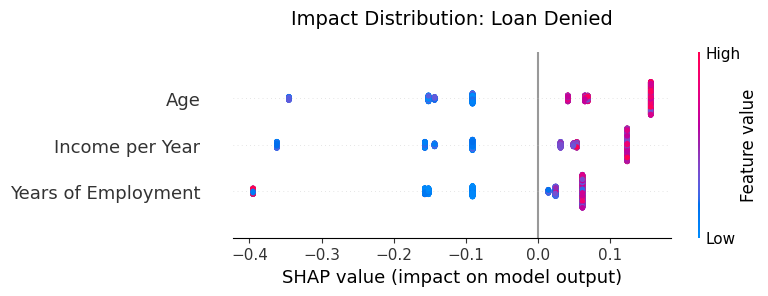

In [2]:

current_shap_raw = np.array(all_shap_dict[0])
s_flat, d_flat, names = get_flattened_data(current_shap_raw)
plt.figure(figsize=(10, 6))
shap.summary_plot(s_flat, d_flat, feature_names=names, show=False)
plt.title(f"Impact Distribution: Loan Denied", fontsize=14, pad=20)
plt.show()

### 2. Global Feature Importance
**What is this?** The mean absolute SHAP value for each feature.  
**What to focus on:** The length of the bar. It represents the "global" influence of a feature—how much it moves the prediction on average, regardless of direction.

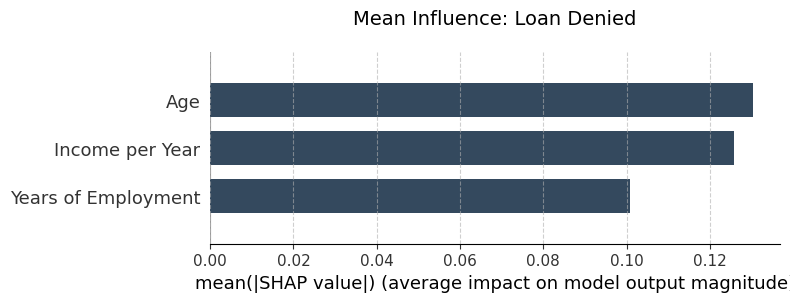

In [3]:

plt.figure(figsize=(10, 6))
shap.summary_plot(s_flat, d_flat, feature_names=names, plot_type='bar', show=False, color='#34495e')
plt.title(f"Mean Influence: Loan Denied", fontsize=14, pad=20)
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.show()

### 4. Focused View: Top 5 Drivers
**What is this?** A high-precision look at the five most critical variables for `Loan Denied`.  
**What to focus on:** The gap between the 1st and 5th feature. If the 1st is much larger, the model is heavily reliant on a single "smoking gun" variable.

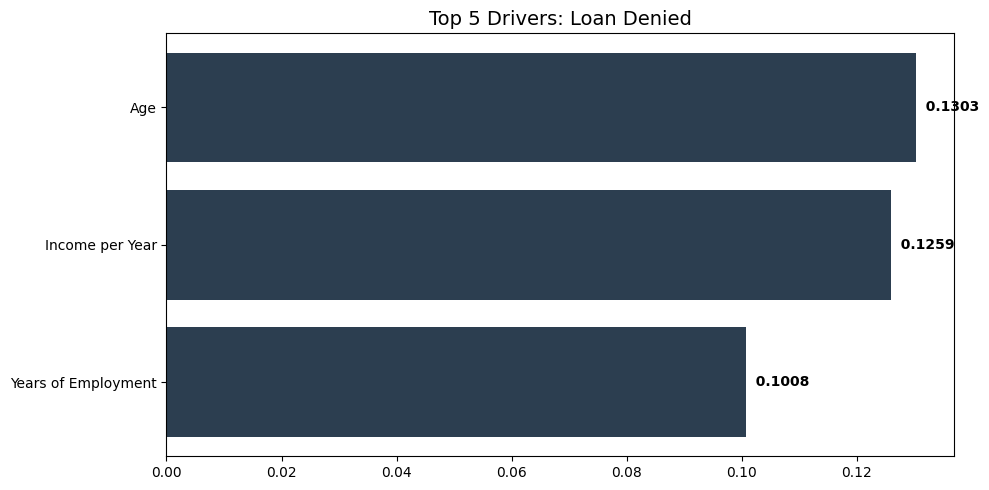

In [4]:

mean_shap = np.abs(s_flat).mean(axis=0)
sorted_idx = np.argsort(mean_shap)[-5:]
plt.figure(figsize=(10, 5))
plt.barh([names[i] for i in sorted_idx], mean_shap[sorted_idx], color='#2c3e50')
plt.title(f"Top 5 Drivers: Loan Denied", fontsize=14)
for i, v in enumerate(mean_shap[sorted_idx]):
    plt.text(v, i, f"  {v:.4f}", va='center', fontweight='bold')
plt.tight_layout()
plt.show()

--- 
# Analysis for: **Loan Approved**

## 🎯 Analysis for Target: `Loan Approved`
---

### 1. Feature Impact Distribution (Beeswarm)
**What is this?** A distribution of SHAP values for every sample in the dataset.  
**What to focus on:** * **Horizontal Position:** Points to the right increase the model output; points to the left decrease it.
* **Color:** Represents the feature value (**Red** is high, **Blue** is low). 
* **Insight:** If Red points are on the right, the feature has a positive correlation with the target.

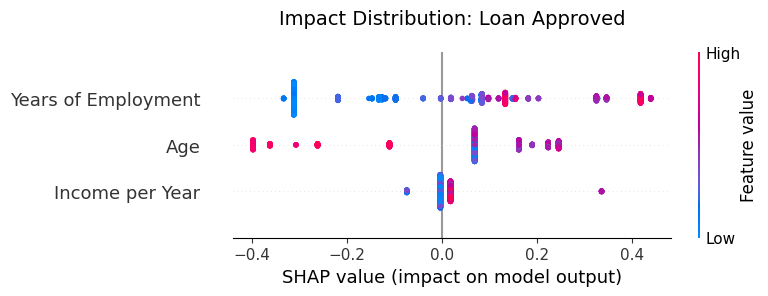

In [5]:

current_shap_raw = np.array(all_shap_dict[1])
s_flat, d_flat, names = get_flattened_data(current_shap_raw)
plt.figure(figsize=(10, 6))
shap.summary_plot(s_flat, d_flat, feature_names=names, show=False)
plt.title(f"Impact Distribution: Loan Approved", fontsize=14, pad=20)
plt.show()

### 2. Global Feature Importance
**What is this?** The mean absolute SHAP value for each feature.  
**What to focus on:** The length of the bar. It represents the "global" influence of a feature—how much it moves the prediction on average, regardless of direction.

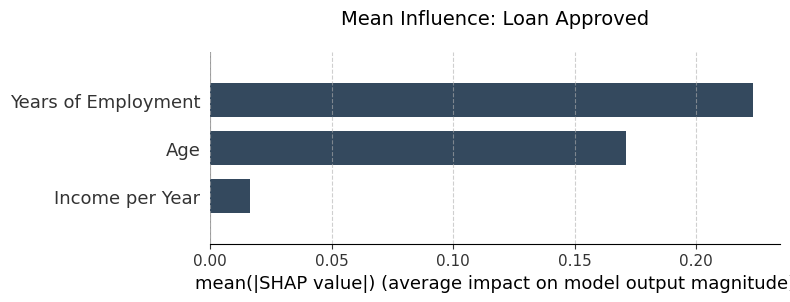

In [6]:

plt.figure(figsize=(10, 6))
shap.summary_plot(s_flat, d_flat, feature_names=names, plot_type='bar', show=False, color='#34495e')
plt.title(f"Mean Influence: Loan Approved", fontsize=14, pad=20)
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.show()

### 4. Focused View: Top 5 Drivers
**What is this?** A high-precision look at the five most critical variables for `Loan Approved`.  
**What to focus on:** The gap between the 1st and 5th feature. If the 1st is much larger, the model is heavily reliant on a single "smoking gun" variable.

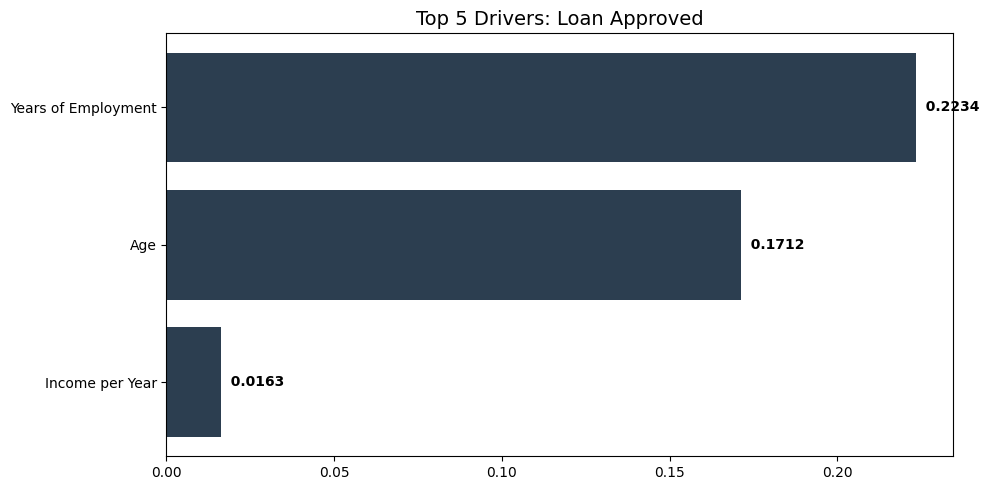

In [7]:

mean_shap = np.abs(s_flat).mean(axis=0)
sorted_idx = np.argsort(mean_shap)[-5:]
plt.figure(figsize=(10, 5))
plt.barh([names[i] for i in sorted_idx], mean_shap[sorted_idx], color='#2c3e50')
plt.title(f"Top 5 Drivers: Loan Approved", fontsize=14)
for i, v in enumerate(mean_shap[sorted_idx]):
    plt.text(v, i, f"  {v:.4f}", va='center', fontweight='bold')
plt.tight_layout()
plt.show()